## Setup and Configuration

In [1]:
# Imports
import numpy as np
import os
import pandas as pd
from pathlib import Path
import sys
from collections import defaultdict
from itertools import product

# Add project root to path
ROOT = Path.cwd().parents[1]  # Assumes notebook is in projects/MOSAIC/notebooks/
sys.path.append(str(ROOT))
sys.path.append(str(ROOT / "src"))

# Import project-specific utilities
from pose_dynamics.projects.MOSAIC import (
    PREDEFINED_SETS,
    extract_keypoints,
    preprocess_mosaic_trial,
    get_window_indices,
    build_symmetric_template,
    compute_reference_limb_lengths,
    batch_apply_fixed_lengths,
    align_keypoints,
    rebuild_aligned_dataframe,
    compute_velocity,
    compute_linear_metrics
)

from pose_dynamics.projects.MOSAIC.alignment import order_xy_pairs
from pose_dynamics.projects.MOSAIC.visualization import (
    plot_alignment_diagnostics
)

# Import RQA-specific utilities (C++ backend compiled and ready)
from pose_dynamics.nonlinear.rqa_utils import cross_rqa, auto_rqa, make_rqa_params

print("✓ Imports successful")

✓ Imports successful


## Parameters

In [14]:
# Data Configuration
DATA_PATH = "G:/mosaic movement files"  # Folder containing participant CSV files
AUDIO_CONDITIONS_CSV = "Mosaic_Conditions.csv"  # CSV with session, trial, condition columns

# ROI Configuration
# Use predefined keypoint sets (from PREDEFINED_SETS) for ROI extraction
ROI_KEYPOINT_SETS = ['center_face', 'body', 'arm']

# Processing Parameters
CONF_THRESHOLD = 0.3
MAX_INTERP_GAP = 60 # 1 second at 60 FPS (implemented before downsampling)
FILTER_CUTOFF = 10.0
FILTER_ORDER = 4
FPS = 60
TARGET_FPS = 30  # Set to downsample (e.g., 30 for 30 Hz), None to keep original

# Window Parameters
WINDOW_SIZE = 60      # 60 seconds
WINDOW_OVERLAP = 0.5  # 50% overlap (30 seconds)

# RQA/CRQA Parameters
TIME_LAGS = [10] # [5, 10, 15]
EMBEDDING_DIMS = [4] # [3, 4, 5]
RADII = [.2] #[0.1, 0.15, 0.2]

# Alignment Parameters
SYMMETRIZATION_MODE = "none"  # Options: "none", "nose", "torso", "full"
ALLOW_ROTATION = True

# Analysis Target
# The pipeline analyzes VELOCITY MAGNITUDE (not position) because:
#   1. Procrustes alignment + trial-centering remove positional meaning (arbitrary origin)
#   2. Velocity magnitude = movement speed (origin-independent, meaningful signal)
#   3. All analyses (CRQA/RQA/Linear) consistently analyze movement dynamics
#   4. More interpretable for interpersonal coordination (synchrony of movement, not posture)
USE_VELOCITY = True

# Output Directories
os.makedirs("../crqa_results", exist_ok=True)
os.makedirs("../rqa_results", exist_ok=True)
os.makedirs("../animations", exist_ok=True)
os.makedirs("../linear_results", exist_ok=True)

print("✓ Parameters configured")

✓ Parameters configured


## Pass 1: Load Data and Build Global Template

This pass:
1. Loads all session/trial pose files
2. Extracts relevant keypoints
3. Preprocesses (normalize, mask, interpolate, filter)
4. Slices into windows
5. Builds global symmetric template from all data

In [3]:
raw_windows = []   # (window_df, metadata)
full_trials = []   # for template building
expected_cols = None 

print("Loading and preprocessing data...")

# Load audio conditions
audio_df = pd.read_csv(AUDIO_CONDITIONS_CSV)
condition_map = {(int(r["session"]), int(r["trial"])): r["condition"] for _, r in audio_df.iterrows()}
print(f"✓ Loaded audio conditions for {len(condition_map)} session/trial combinations")

# Select ROI keypoints only for analysis
ROI_KEYPOINT_SETS = ["center_face", "arm", "body"]

print("Processing trials...")

# Iterate over all session/trial combinations in condition map
for session_number, trial_number in sorted(condition_map.keys()):
    condition = condition_map[(session_number, trial_number)]

    # Process Left and Right participants
    for role, suffix in [("Left", "left"), ("Right", "right")]:

        # Construct filename
        filename = f"S{session_number:03}_T{trial_number}_{suffix}.csv"
        filepath = os.path.join(DATA_PATH, filename)

        # Check file existence
        if not os.path.exists(filepath):
            print(f"[SKIP] {filename} not found")
            continue
        try:
            raw_data = pd.read_csv(filepath)

            # Select ROI keypoints only for analysis
            selected = extract_keypoints(raw_data, sets=ROI_KEYPOINT_SETS)

            # Ensure consistent column order across trials
            if expected_cols is None and not selected.empty:
                expected_cols = order_xy_pairs(selected.columns)
                print(f"✓ Column order established: {len(expected_cols)} columns ({len(expected_cols)//2} keypoints)")

            # Preprocess data (remove low confidence, interpolate, filter, downsample)
            preprocessed = preprocess_mosaic_trial(
                selected,
                expected_cols,
                conf_threshold=CONF_THRESHOLD,
                max_interp_gap=MAX_INTERP_GAP,
                filter_cutoff=FILTER_CUTOFF,
                filter_order=FILTER_ORDER,
                fps=FPS,
                target_fps=TARGET_FPS
            )

            # Store full preprocessed trials for template building
            full_trials.append(preprocessed)

            # Determine effective FPS after potential downsampling
            eff_fps = TARGET_FPS if TARGET_FPS is not None else FPS

            # Convert seconds to frames for windowing
            ws_frames = int(round(WINDOW_SIZE * eff_fps))

            # Segment data into overlapping windows
            win_indices = get_window_indices(len(preprocessed), ws_frames, WINDOW_OVERLAP)
            for w_idx, (start, end) in enumerate(win_indices):
                window = preprocessed.iloc[start:end].reset_index(drop=True)

                # Store window with metadata
                meta = {
                    "Session": session_number,
                    "Trial": trial_number,
                    "Role": role,
                    "Condition": condition,
                    "Window_Size": WINDOW_SIZE, 
                    "Window_Index": w_idx,
                    "Effective_FPS": eff_fps,        
                    "Window_Size_Frames": ws_frames  
                }

                # Check for NaNs or insufficient length
                if window.isnull().any().any() or len(window) < ws_frames:
                    raw_windows.append((None, meta))
                else:
                    raw_windows.append((window, meta))

        # Flag any errors during processing
        except Exception as e:
            print(f"Error processing S{session_number:03} T{trial_number} {role}: {e}")
            continue

# Flag total valid windows loaded
print(f"\n✓ Loaded {len([w for w, _ in raw_windows if w is not None])} valid windows from {len(full_trials)} trials")

if not full_trials:
    raise ValueError("No valid trials found for template building")

# Build global template from all trials
X_raw = pd.concat(full_trials, ignore_index=True).dropna().astype(np.float32)
global_template = build_symmetric_template(X_raw, expected_cols, mode=SYMMETRIZATION_MODE)
print(f"✓ Global template built: {global_template.shape} with mode='{SYMMETRIZATION_MODE}'")

# Compute reference limb lengths
ref_lengths = None if SYMMETRIZATION_MODE == "nose" else compute_reference_limb_lengths(global_template, expected_cols)
if ref_lengths:
    print(f"✓ Reference limb lengths computed: {len(ref_lengths)} segments")


Loading and preprocessing data...
✓ Loaded audio conditions for 278 session/trial combinations
Processing trials...
✓ Column order established: 124 columns (62 keypoints)
[SKIP] S014_T1_left.csv not found
[SKIP] S014_T2_left.csv not found
[SKIP] S014_T3_left.csv not found
[SKIP] S014_T4_left.csv not found
[SKIP] S014_T5_left.csv not found
[SKIP] S014_T6_left.csv not found

✓ Loaded 5576 valid windows from 550 trials
✓ Global template built: (62, 2) with mode='none'
✓ Reference limb lengths computed: 4 segments


## Alignment Diagnostics

Visualize alignment quality by comparing raw, aligned, and limb-rescaled poses.

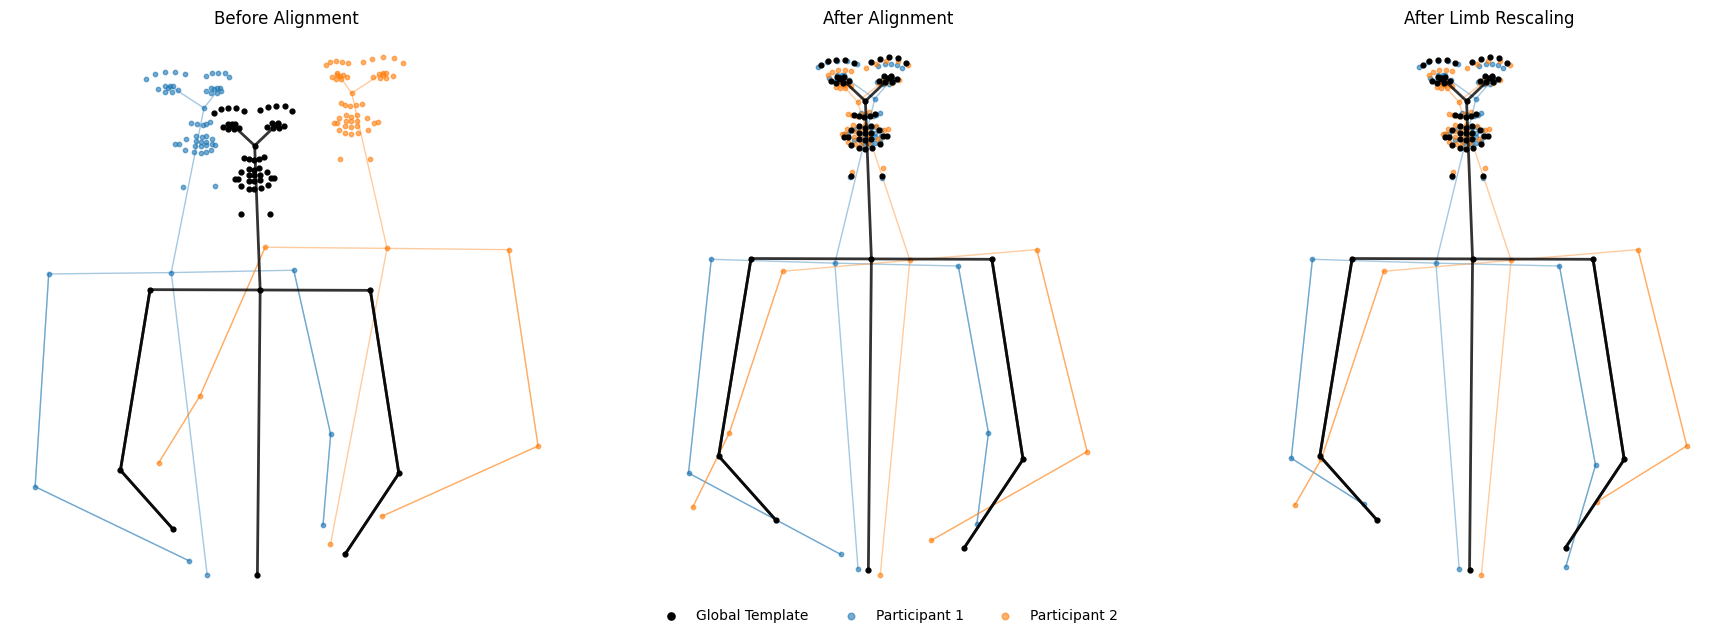

In [4]:
# Sample windows from both Left and Right roles for balanced visualization
valid_windows = [w for w in raw_windows if w[0] is not None]

# Separate by role
left_windows = [(w, m) for w, m in valid_windows if m['Role'] == 'Left']
right_windows = [(w, m) for w, m in valid_windows if m['Role'] == 'Right']

# Take samples from each role
sample_windows = []
n_per_role = 1 # Number of windows to sample per role
if left_windows:
    sample_windows.extend(left_windows[:n_per_role])
if right_windows:
    sample_windows.extend(right_windows[:n_per_role])

# Plot alignment diagnostics for sampled windows
plot_alignment_diagnostics(
    global_template=global_template,
    raw_windows=sample_windows,
    expected_cols=expected_cols,
    align_keypoints=align_keypoints,
    n_samples=len(sample_windows),
    procrustes=True,
    allow_rotation=ALLOW_ROTATION,
    ref_lengths=ref_lengths,
    reference="Torso"
)

## Pass 2: Align Windows and Prepare for Analysis

This pass:
1. Aligns all windows to global template using Procrustes
2. Applies limb length constraints
3. Computes velocity (via finite differences)
4. Centers data per trial (removes camera angle effects)

Note: Velocity is computed by default because it's origin-independent and more interpretable for coordination analysis than position after normalization.

In [5]:
aligned_windows = []
metadata = []

print("Aligning windows...")

# Set FPS after downsampling earlier (required for velocity computation)
eff_fps = TARGET_FPS if TARGET_FPS is not None else FPS

# Window-level procrustes alignment
# - each window is aligned to the global template

# Iterate over all raw windows
for window, meta in raw_windows:
    # Append empty if window is None
    if window is None:
        aligned_windows.append(None)
        metadata.append(meta)
        continue

    try:
        # Extract XY columns only
        window_xy = window[expected_cols]

        # Procrustes alignment to global template
        # - reference landmark defines origin (Torso or Nose)
        # - rotation and scale are allowed to remove viewpoint differences
        aligned_X, _ = align_keypoints(
            window_xy,
            expected_cols,
            reference="Torso" if SYMMETRIZATION_MODE != "nose" else "Nose",
            template=global_template,
            use_procrustes=True,
            allow_rotation=ALLOW_ROTATION,
            allow_scale=True
        )

        # Reshape to (frames, keypoints, 2) for optional-limb length correction
        poses = aligned_X.reshape(-1, len(expected_cols) // 2, 2)

        # Apply reference limb lengths if available
        if ref_lengths:
            poses = batch_apply_fixed_lengths(poses, ref_lengths)

        # Convert back to DataFrame with original column names
        aligned_df = rebuild_aligned_dataframe(
            poses.reshape(-1, len(expected_cols)),
            expected_cols
        )

        # Store aligned window and metadata
        aligned_windows.append(aligned_df)
        metadata.append(meta)

    # Flag any alignment errors
    except Exception as e:
        aligned_windows.append(None)
        metadata.append(meta)
        print(f"[ALIGN SKIP] S{meta['Session']:03} T{meta['Trial']} {meta['Role']} W{meta['Window_Index']}: {e}")

print(f"✓ Aligned {sum(w is not None for w in aligned_windows)} windows")

# Trial-centered normalization on position (xy) then calculate velocity
# - removes trial-level biases in position
# - computes velocity after centering to retain meaningful movement dynamics

# Group windows by (Session, Trial, Role)
trial_groups = defaultdict(list)
for i, meta in enumerate(metadata):
    df = aligned_windows[i]
    if df is None:
        continue
    key = (meta["Session"], meta["Trial"], meta["Role"])
    trial_groups[key].append((i, df))

# Initialize final windows list
final_windows = [None] * len(aligned_windows)

# Process each trial group
for indices_and_data in trial_groups.values():

    # Compute trial mean on position columns
    trial_df = pd.concat([df for _, df in indices_and_data], ignore_index=True)
    trial_mean = trial_df.mean(numeric_only=True)

    # Apply centering and velocity computation to each window in the trial
    for idx, df in indices_and_data:

        # Centre positions first
        centred = df - trial_mean

        # Then compute velocity (signed vx/vy)
        if USE_VELOCITY:
            centred = compute_velocity(centred, fps=eff_fps)

        final_windows[idx] = centred

print("✓ Trial-centered normalization complete and velocity computed")


Aligning windows...
✓ Aligned 5576 windows
✓ Trial-centered normalization complete and velocity computed


## Pass 3: Extract ROI Magnitude Vectors

Collapse each ROI's keypoint data into a single value per frame:
- Compute centroid: mean (x, y) across all keypoints in ROI
- Compute magnitude: Euclidean norm of centroid
- Result: single scalar time series per ROI (speed if velocity, position if USE_VELOCITY=False)

Regions of Interest:
- **Centre-face**: Central facial and head region

- **Upper body**: Torso and shoulder region

- **Arms**: Upper and lower arm movements

These collapsed vectors are then analyzed by CRQA (dyadic), RQA (individual), and linear metrics (descriptive).

In [6]:
# Helper functions for ROI extraction
def build_roi_columns(expected_cols):
    """
    Build ROI -> (x_cols, y_cols) from the columns that actually exist.

    Works for:
      - position columns: *_x_offset, *_y_offset
      - velocity columns: *_vx, *_vy
    """

    # Determine if working with velocity or position columns
    is_velocity = any(c.endswith("_vx") or c.endswith("_vy") for c in expected_cols)
    
    # Choose suffixes accordingly
    x_suffix = "_vx" if is_velocity else "_x_offset"
    y_suffix = "_vy" if is_velocity else "_y_offset"

    roi_map = {}

    # --- centre_face ---
    bases = PREDEFINED_SETS["center_face"]
    x_cols = [c for c in expected_cols if c.endswith(x_suffix) and any(b in c for b in bases)]
    y_cols = [c for c in expected_cols if c.endswith(y_suffix) and any(b in c for b in bases)]
    roi_map["center_face"] = (x_cols, y_cols)

    # --- body ---
    bases = PREDEFINED_SETS["body"]
    x_cols = [c for c in expected_cols if c.endswith(x_suffix) and any(b in c for b in bases)]
    y_cols = [c for c in expected_cols if c.endswith(y_suffix) and any(b in c for b in bases)]
    roi_map["body"] = (x_cols, y_cols)

    # --- arms (combined) ---
    arm_bases = PREDEFINED_SETS["arm"]  # ["Shoulder", "Elbow", "Wrist"]
    x_cols = [c for c in expected_cols if c.endswith(x_suffix) and any(b in c for b in arm_bases)]
    y_cols = [c for c in expected_cols if c.endswith(y_suffix) and any(b in c for b in arm_bases)]
    roi_map["arms"] = (x_cols, y_cols)

    return roi_map


def collapse_window_to_roi_timeseries(window_df: pd.DataFrame, x_cols, y_cols, roi_name: str) -> pd.DataFrame:
    """
    Collapse ROI keypoints to into single ROI time series.
    Computes: 
    - centroid x (mean across ROI x-columns per frame)
      - centroid y (mean across ROI y-columns per frame)
      - magnitude:
          * velocity: speed = sqrt(vx^2 + vy^2)  (meaningful, origin-invariant)
          * position: sqrt(x^2 + y^2)            (less meaningful post-alignment, but supported)
    """
    # Guardrail: if ROI matching failed (e.g., naming mismatch), raise a clear error
    if len(x_cols) == 0 or len(y_cols) == 0:
        raise ValueError(f"{roi_name}: no matching columns found (x={len(x_cols)}, y={len(y_cols)})")

    # Centroid = mean position/velocity across ROI keypoints per frame
    cx = window_df[x_cols].mean(axis=1)
    cy = window_df[y_cols].mean(axis=1)

    # Magnitude summary (speed for velocity, radial magnitude for position)
    mag = np.sqrt(cx**2 + cy**2)

    # Return DataFrame with centroid (x, y) and magnitude
    return pd.DataFrame({
        f"{roi_name}_x": cx,
        f"{roi_name}_y": cy,
        f"{roi_name}_mag": mag
    })


# Choose which windows to collapse
# - Recommended:
#   * If USE_VELOCITY=True and you followed the earlier fix:
#       final_windows contains vx/vy already -> collapse those
#   * If USE_VELOCITY=False:
#       use aligned_windows (trial-centered positions if you created them)

windows_for_roi = final_windows if USE_VELOCITY else aligned_windows

# Grab a representative non-None window to detect column suffixes
first_valid_idx = next(i for i, w in enumerate(windows_for_roi) if w is not None)
cols_in_use = list(windows_for_roi[first_valid_idx].columns)

# Build ROI -> (x_cols, y_cols) mapping using the actual columns present
roi_map = build_roi_columns(cols_in_use)

# Prepare per-ROI containers:
# each ROI gets a list aligned to the original window order (including None entries)
roi_windows = {roi: [] for roi in roi_map.keys()}
roi_metadata = {roi: [] for roi in roi_map.keys()}

print("Extracting ROI centroid + magnitude...")

# Iterate over all windows to extract ROI summaries
for w, meta in zip(windows_for_roi, metadata):

    # If window is missing, append None for all ROIs
    if w is None:
        for roi in roi_windows:
            roi_windows[roi].append(None)
            roi_metadata[roi].append(meta)
        continue

    # For each ROI, collapse that window to a centroid + magnitude time series
    for roi, (x_cols, y_cols) in roi_map.items():
        try:
            roi_df = collapse_window_to_roi_timeseries(w, x_cols, y_cols, roi)

            meta_roi = meta.copy()
            meta_roi["ROI"] = roi
            meta_roi["ROI_n_keypoints"] = len(x_cols)
            meta_roi["ROI_signal"] = "speed" if USE_VELOCITY else "position_magnitude"

            roi_windows[roi].append(roi_df)
            roi_metadata[roi].append(meta_roi)

        except Exception as e:
            # Flag any ROI extraction errors
            print(f"[ROI SKIP] {roi} S{meta['Session']:03} T{meta['Trial']} {meta['Role']} W{meta['Window_Index']}: {e}")
            roi_windows[roi].append(None)
            roi_metadata[roi].append(meta)

print("\nROI extraction diagnostics:")
for roi in roi_windows:
    # Count valid windows for each ROI
    n_valid = sum(df is not None for df in roi_windows[roi])
    print(f"  {roi:>11}: {n_valid} valid windows")


Extracting ROI centroid + magnitude...

ROI extraction diagnostics:
  center_face: 5576 valid windows
         body: 5576 valid windows
         arms: 5576 valid windows


## Pass X: Save ROI-window outputs

This saves each valid window for each ROI into a parquet file for easy loading into downstream (linear and non-linear) analyses.

In [ ]:
from pathlib import Path

CACHE_DIR = Path("cache_roi_windows")
CACHE_DIR.mkdir(exist_ok=True)

def cache_roi_windows_long(roi_windows, roi_metadata, cache_dir=CACHE_DIR):
    """
    Save each ROI's windows into a single long-format parquet:
      one row per frame within each window, with metadata attached.
    """
    for roi, win_list in roi_windows.items():
        rows = []

        for w, meta in zip(win_list, roi_metadata[roi]):
            if w is None:
                continue

            w2 = w.copy()
            # add a within-window time index
            w2["frame_in_window"] = np.arange(len(w2), dtype=int)

            # attach metadata to every row
            for k, v in meta.items():
                w2[k] = v

            rows.append(w2)

        if not rows:
            print(f"[CACHE SKIP] {roi}: no valid windows to save")
            continue

        out = pd.concat(rows, ignore_index=True)

        fp = cache_dir / f"roi_{roi}_windows.parquet"
        out.to_parquet(fp, index=False)
        print(f"[CACHE SAVED] {roi}: {out.shape} -> {fp}")

cache_roi_windows_long(roi_windows, roi_metadata)

## Pass 4: (C)RQA Parameter Setting

Average Mutual Information

AMI inputs (stratified; after sampling):
  center_face: total=400  (Office=100, Food=100, Cafe=100, Party=100)
         body: total=400  (Office=100, Food=100, Cafe=100, Party=100)
         arms: total=400  (Office=100, Food=100, Cafe=100, Party=100)


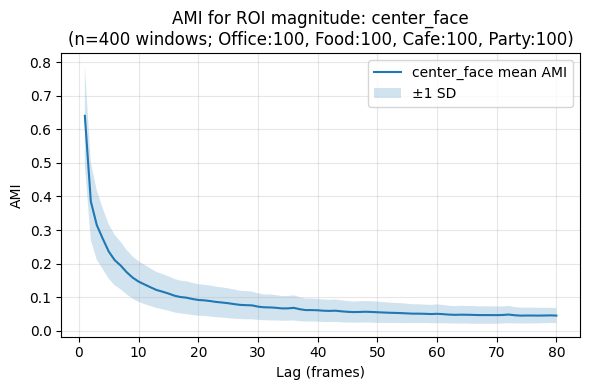

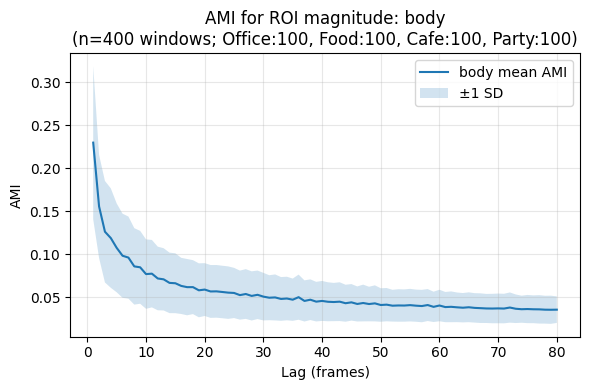

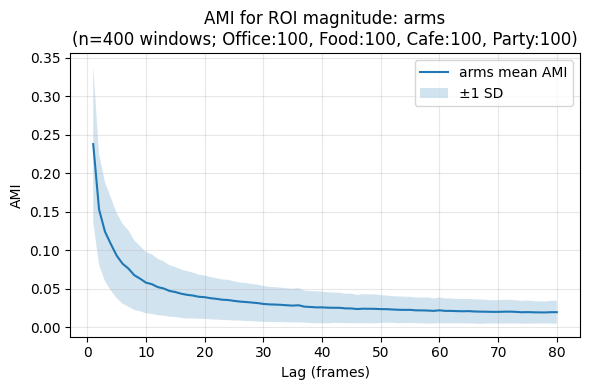

In [7]:
# ============================================================
# AMI (Average Mutual Information) per ROI magnitude vector
# Stratified sampling by Condition + SD band
# ============================================================

from pose_dynamics.nonlinear.state_space_recon import compute_ami_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

AMI_MIN_LAG = 1
AMI_MAX_LAG = 80

# ---- Sampling + plotting toggles ----
N_WINDOWS_PER_CONDITION = 100   # up to this many windows per ROI *per Condition*
RANDOM_SEED = 123               # reproducible sampling
SHOW_SD_BAND = True             # plot ±1 SD across sampled windows

# Optional: minimum length guardrail (in frames)
MIN_SIGNAL_LEN = AMI_MAX_LAG + 5

rng = np.random.default_rng(RANDOM_SEED)

# ---------
# 1) Build signals_per_roi_condition: ROI -> Condition -> list of signals
# ---------
signals_per_roi_condition = {}

for roi, win_list in roi_windows.items():
    mag_col = f"{roi}_mag"
    by_cond = {}  # Condition -> list of signals

    # iterate windows + their metadata (so we can stratify by Condition)
    for w, meta in zip(win_list, roi_metadata[roi]):
        if w is None:
            continue

        cond = meta.get("Condition", None)
        if cond is None:
            # fallback: try to infer from DF if present (rare)
            cond = meta.get("condition", None)

        if cond is None:
            continue

        if mag_col not in w.columns:
            continue

        sig = pd.to_numeric(w[mag_col], errors="coerce").to_numpy()
        sig = sig[np.isfinite(sig)]
        if sig.size < MIN_SIGNAL_LEN:
            continue

        sig = sig - np.mean(sig)  # optional demean
        by_cond.setdefault(str(cond), []).append(sig)

    # stratified sample per condition
    by_cond_sampled = {}
    for cond, series_list in by_cond.items():
        if len(series_list) > N_WINDOWS_PER_CONDITION:
            idx = rng.choice(len(series_list), size=N_WINDOWS_PER_CONDITION, replace=False)
            series_list = [series_list[i] for i in idx]
        by_cond_sampled[cond] = series_list

    signals_per_roi_condition[roi] = by_cond_sampled

print("AMI inputs (stratified; after sampling):")
for roi, d in signals_per_roi_condition.items():
    counts = ", ".join([f"{c}={len(v)}" for c, v in d.items()])
    total = sum(len(v) for v in d.values())
    print(f"  {roi:>11}: total={total}  ({counts})")

# ---------
# 2) Compute AMI per ROI using all sampled windows (across all conditions)
# ---------
ami_summary = {}  # roi -> dict with lags, mean, std, n_signals

for roi, cond_dict in signals_per_roi_condition.items():
    # flatten sampled signals across conditions
    series_list = []
    for cond, lst in cond_dict.items():
        series_list.extend(lst)

    if not series_list:
        print(f"[AMI SKIP] ROI={roi}: no sampled signals")
        continue

    lags_ref = None
    all_ami = []

    for sig in series_list:
        res = compute_ami_curve(sig, min_lag=AMI_MIN_LAG, max_lag=AMI_MAX_LAG)
        if res is None:
            continue

        lags = res["lags"]
        vals = res["ami"]

        if lags_ref is None:
            lags_ref = lags
        else:
            if not np.array_equal(lags, lags_ref):
                continue

        all_ami.append(vals)

    if not all_ami or lags_ref is None:
        print(f"[AMI SKIP] No valid AMI results for ROI={roi}")
        continue

    all_ami = np.vstack(all_ami)  # (n_signals, n_lags)
    mean_ami = np.nanmean(all_ami, axis=0)
    std_ami  = np.nanstd(all_ami, axis=0)  # SD across windows
    n_signals = all_ami.shape[0]

    ami_summary[roi] = {
        "lags": lags_ref,
        "mean_ami": mean_ami,
        "std_ami": std_ami,
        "n_signals": n_signals,
        "n_per_condition": {c: len(v) for c, v in cond_dict.items()},
    }

    # ---------
    # 3) Plot mean ± 1 SD
    # ---------
    plt.figure(figsize=(6, 4))
    plt.plot(lags_ref, mean_ami, label=f"{roi} mean AMI")

    if SHOW_SD_BAND:
        plt.fill_between(
            lags_ref,
            mean_ami - std_ami,
            mean_ami + std_ami,
            alpha=0.2,
            label="±1 SD"
        )

    # annotate counts
    counts_txt = ", ".join([f"{c}:{len(v)}" for c, v in cond_dict.items()])
    plt.xlabel("Lag (frames)")
    plt.ylabel("AMI")
    plt.title(f"AMI for ROI magnitude: {roi}\n(n={n_signals} windows; {counts_txt})")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


False Nearest Neighbours

FNN inputs (stratified; using sampled windows from AMI cell):
  center_face: ok=400/400 (min_len=150)  [Office=100, Food=100, Cafe=100, Party=100]
         body: ok=400/400 (min_len=150)  [Office=100, Food=100, Cafe=100, Party=100]
         arms: ok=400/400 (min_len=150)  [Office=100, Food=100, Cafe=100, Party=100]


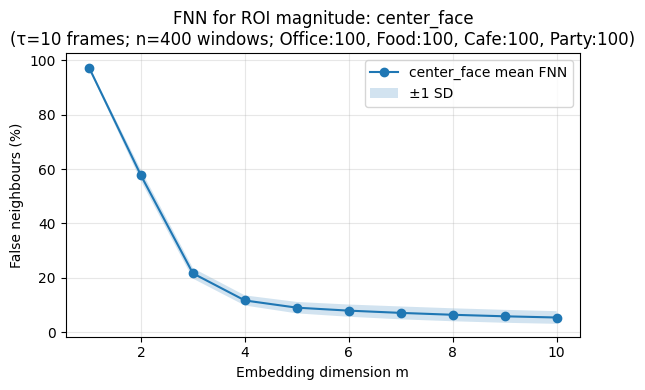

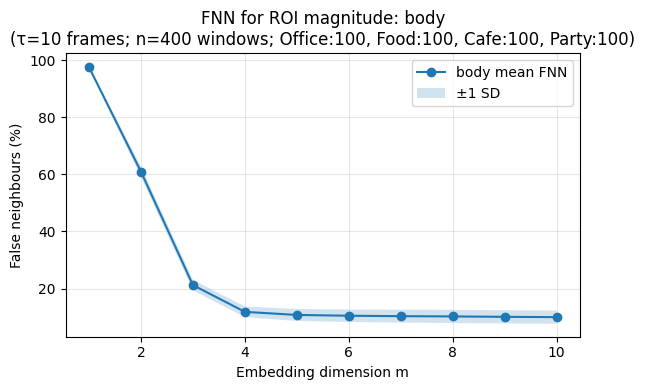

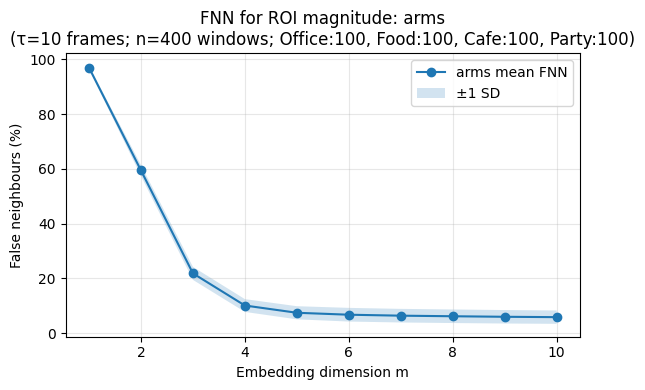

In [8]:
# ============================================================
# FNN (False Nearest Neighbours) per ROI magnitude vector
# Stratified sampling by Condition + SD band
# Place this cell AFTER the AMI cell (reuses signals_per_roi_condition)
# ============================================================

from pose_dynamics.nonlinear.state_space_recon import compute_fnn_curve
import matplotlib.pyplot as plt
import numpy as np

# ---- Choose tau (frames) from your AMI results ----
TAU = 10      # <-- set from AMI (first minimum / knee)
MIN_DIM = 1
MAX_DIM = 10

SHOW_SD_BAND = True

# Optional length guardrail: embedding needs enough samples
# Rule of thumb: N should be comfortably larger than m*tau
MIN_SIGNAL_LEN = (MAX_DIM * TAU) + 50

fnn_summary = {}  # roi -> dict with dims, mean, std, n_signals

print("FNN inputs (stratified; using sampled windows from AMI cell):")
for roi, cond_dict in signals_per_roi_condition.items():
    # count signals passing the length check
    total = 0
    total_ok = 0
    for cond, lst in cond_dict.items():
        total += len(lst)
        total_ok += sum(len(sig) >= MIN_SIGNAL_LEN for sig in lst)
    counts_txt = ", ".join([f"{c}={len(v)}" for c, v in cond_dict.items()])
    print(f"  {roi:>11}: ok={total_ok}/{total} (min_len={MIN_SIGNAL_LEN})  [{counts_txt}]")

for roi, cond_dict in signals_per_roi_condition.items():
    # flatten across conditions (but sampling already stratified upstream)
    series_list = []
    for cond, lst in cond_dict.items():
        series_list.extend(lst)

    if not series_list:
        print(f"[FNN SKIP] ROI={roi}: no sampled signals")
        continue

    dims_ref = None
    all_pct = []

    for sig in series_list:
        if len(sig) < MIN_SIGNAL_LEN:
            continue

        res = compute_fnn_curve(
            sig,
            tau=TAU,
            min_dim=MIN_DIM,
            max_dim=MAX_DIM,
        )
        if res is None:
            continue

        dims = res["dims"]
        pct  = res["pct_fnn"]

        if dims_ref is None:
            dims_ref = dims
        else:
            if not np.array_equal(dims, dims_ref):
                continue

        all_pct.append(pct)

    if not all_pct or dims_ref is None:
        print(f"[FNN SKIP] No valid FNN results for ROI={roi}")
        continue

    all_pct = np.vstack(all_pct)  # (n_signals, n_dims)
    mean_pct = np.nanmean(all_pct, axis=0)
    std_pct  = np.nanstd(all_pct, axis=0)   # SD across windows
    n_signals = all_pct.shape[0]

    fnn_summary[roi] = {
        "dims": dims_ref,
        "mean_pct": mean_pct,
        "std_pct": std_pct,
        "n_signals": n_signals,
        "tau": TAU,
        "n_per_condition": {c: len(v) for c, v in cond_dict.items()},
    }

    # ---- Plot mean ± 1 SD ----
    plt.figure(figsize=(6, 4))
    plt.plot(dims_ref, mean_pct, marker="o", label=f"{roi} mean FNN")

    if SHOW_SD_BAND:
        plt.fill_between(
            dims_ref,
            mean_pct - std_pct,
            mean_pct + std_pct,
            alpha=0.2,
            label="±1 SD"
        )

    counts_txt = ", ".join([f"{c}:{len(v)}" for c, v in cond_dict.items()])
    plt.xlabel("Embedding dimension m")
    plt.ylabel("False neighbours (%)")
    plt.title(f"FNN for ROI magnitude: {roi}\n(τ={TAU} frames; n={n_signals} windows; {counts_txt})")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Pass 4: CRQA Analysis - Movement Synchrony

Analyze interpersonal movement synchrony between Left and Right participants using cross-recurrence on ROI speed magnitude vectors.


Interpretation: How much do the two participants' movements in each ROI co-recur? Higher REC/DET suggests synchronized movement dynamics.

In [15]:
# CRQA on ROI magnitude ly (1D signal per ROI per window)
# - roi_windows[roi] contains DataFrames with columns: f"{roi}_x", f"{roi}_y", f"{roi}_mag"
# - roi_metadata[roi] contains matching metadata dicts (incl. Session/Trial/Role/Condition/Window_Size/Window_Index)

print("\nRunning CRQA on ROI magnitude vectors...")

# Iterate over each ROI
for roi in roi_windows.keys():
    print(f"\n{'='*60}")
    print(f"CRQA ANALYSIS: {roi.upper()} (magnitude only)")
    print(f"{'='*60}")

    # Pair up Left/Right participants by (Session, Trial, Window_Index, Window_Size)
    paired = defaultdict(dict)
    for df_roi, meta in zip(roi_windows[roi], roi_metadata[roi]):
        if df_roi is None:
            continue
        key = (meta["Session"], meta["Trial"], meta["Window_Size"], meta["Window_Index"])
        paired[key][meta["Role"]] = (df_roi, meta)

    print(f"Found {len(paired)} potential window pairs")

    csv_rows = []
    n_pairs_run = 0

    # Iterate over paired windows
    for (sess, trial, w_size, w_idx), roles in paired.items():
        if "Left" not in roles or "Right" not in roles:
            continue

        # Extract Left/Right data and metadata
        left_df, left_meta = roles["Left"]
        right_df, right_meta = roles["Right"]

        # Magnitude (1D) time series for this ROI and window
        left_vec = left_df[f"{roi}_mag"].to_numpy(dtype=float)
        right_vec = right_df[f"{roi}_mag"].to_numpy(dtype=float)

        # Safety: require same length and finite values (z-scoring and distances break with NaNs/Infs)
        if left_vec.shape[0] != right_vec.shape[0]:
            continue
        if not (np.isfinite(left_vec).all() and np.isfinite(right_vec).all()):
            continue

        # Iterate over CRQA parameter combinations
        # - norm="zscore" standardises this window's signal before distances
        for lag, emb_dim, rad in product(TIME_LAGS, EMBEDDING_DIMS, RADII):
            params = make_rqa_params(
                eDim=emb_dim,
                tLag=lag,
                radius=rad,
                norm="zscore",
                rescaleNorm=1,
                tw=0,     # no Theiler window for cross-RQA
                minl=2
            )

            try:
                td, rs, mats, err_code = cross_rqa(
                    left_vec,
                    right_vec,
                    params,
                    return_mats=False
                )
                
                # Print progress every ~250 computations
                if n_pairs_run % 250 == 0:
                    rec_val = rs.get("perc_recur", np.nan)
                    print(f"[CRQA] S{sess:03} T{trial} W{w_idx} -> REC={rec_val:.2f}% (lag={lag}, m={emb_dim}, r={rad})")

                # Store results
                csv_rows.append({
                    "Session": sess,
                    "Trial": trial,
                    "Condition": left_meta.get("Condition", np.nan),
                    "Window_Size": left_meta.get("Window_Size", np.nan),
                    "Window_Index": w_idx,
                    "ROI": roi,
                    "Vector_Type": "magnitude",
                    "Lag": lag,
                    "Embedding_Dim": emb_dim,
                    "Radius": rad,
                    "CRQA_REC": rs.get("perc_recur", np.nan),
                    "CRQA_DET": rs.get("perc_determ", np.nan),
                    "CRQA_Lmean": rs.get("mean_line_length", np.nan),
                    "CRQA_Lmax": rs.get("maxl_found", np.nan),
                    "CRQA_ENT": rs.get("entropy", np.nan),
                    "CRQA_LAM": rs.get("laminarity", np.nan),
                    "CRQA_TT": rs.get("trapping_time", np.nan),
                })

                n_pairs_run += 1

            # Flag any CRQA errors
            except Exception as e:
                print(f"[ERROR] CRQA failed S{sess:03} T{trial} W{w_idx} ROI={roi}: {e}")
                # Store NaNs for failed CRQA
                csv_rows.append({
                    "Session": sess,
                    "Trial": trial,
                    "Condition": left_meta.get("Condition", np.nan),
                    "Window_Size": left_meta.get("Window_Size", np.nan),
                    "Window_Index": w_idx,
                    "ROI": roi,
                    "Vector_Type": "magnitude",
                    "Lag": lag,
                    "Embedding_Dim": emb_dim,
                    "Radius": rad,
                    "CRQA_REC": np.nan,
                    "CRQA_DET": np.nan,
                    "CRQA_Lmean": np.nan,
                    "CRQA_Lmax": np.nan,
                    "CRQA_ENT": np.nan,
                    "CRQA_LAM": np.nan,
                    "CRQA_TT": np.nan,
                })

    # Save a file per ROI
    if csv_rows:
        out_path = f"../crqa_results/crqa_{roi}_mag.csv"
        pd.DataFrame(csv_rows).to_csv(out_path, index=False)
        print(f"✓ CRQA results saved → {out_path}  (rows={len(csv_rows)})")
    else:
        print(f"⚠ No valid CRQA results for ROI={roi}")

print(f"\n{'='*60}")
print("CRQA ANALYSIS COMPLETE")
print(f"{'='*60}\n")



Running CRQA on ROI magnitude vectors...

CRQA ANALYSIS: CENTER_FACE (magnitude only)
Found 3114 potential window pairs
[CRQA] S002 T1 W0 -> REC=4.22% (lag=10, m=4, r=0.2)
[CRQA] S006 T5 W6 -> REC=2.81% (lag=10, m=4, r=0.2)
[CRQA] S011 T2 W4 -> REC=1.93% (lag=10, m=4, r=0.2)
[CRQA] S016 T4 W9 -> REC=2.82% (lag=10, m=4, r=0.2)
[CRQA] S020 T3 W7 -> REC=4.16% (lag=10, m=4, r=0.2)
[CRQA] S024 T4 W13 -> REC=3.09% (lag=10, m=4, r=0.2)
[CRQA] S029 T1 W3 -> REC=2.20% (lag=10, m=4, r=0.2)
[CRQA] S033 T6 W7 -> REC=7.50% (lag=10, m=4, r=0.2)
[CRQA] S040 T1 W6 -> REC=1.02% (lag=10, m=4, r=0.2)
[CRQA] S046 T2 W7 -> REC=4.01% (lag=10, m=4, r=0.2)
✓ CRQA results saved → ../crqa_results/crqa_center_face_mag.csv  (rows=2462)

CRQA ANALYSIS: BODY (magnitude only)
Found 3114 potential window pairs
[CRQA] S002 T1 W0 -> REC=0.75% (lag=10, m=4, r=0.2)
[CRQA] S006 T5 W6 -> REC=0.86% (lag=10, m=4, r=0.2)
[CRQA] S011 T2 W4 -> REC=0.96% (lag=10, m=4, r=0.2)
[CRQA] S016 T4 W9 -> REC=1.15% (lag=10, m=4, r=0.2)
[

## Pass 5: RQA Analysis - Individual Movement Dynamics

Analyze recurrence patterns within each individual's ROI speed magnitude trajectories.


Interpretation: How predictable/structured is each person's movement in each ROI? Higher REC/DET suggests more periodic/repetitive movement patterns.

In [16]:
# RQA on ROI magnitude only (1D signal per ROI per window per role)
# - roi_windows[roi] : list of ROI DataFrames (or None), each has f"{roi}_mag"
# - roi_metadata[roi]: matching list of metadata dicts

print("\nRunning RQA on ROI magnitude vectors...")

# Iterate over each ROI
for roi in roi_windows.keys():
    print(f"\n{'='*60}")
    print(f"RQA ANALYSIS: {roi.upper()} (magnitude only)")
    print(f"{'='*60}")

    csv_rows = []
    n_run = 0  # counts individual RQA computations (window × parameter combo)

    roi_list = roi_windows[roi]
    meta_list = roi_metadata[roi]

    print(f"\nRunning RQA on magnitude vectors ({len(meta_list)} windows)...")

    # Iterate over all windows for this ROI (across session/trial/role)
    for df_roi, meta in zip(roi_list, meta_list):

        # If missing window, store NaNs for all parameter combinations
        if df_roi is None:
            for lag, emb_dim, rad in product(TIME_LAGS, EMBEDDING_DIMS, RADII):
                csv_rows.append({
                    "Session": meta["Session"],
                    "Trial": meta["Trial"],
                    "Role": meta["Role"],
                    "Condition": meta.get("Condition", np.nan),
                    "Window_Size": meta.get("Window_Size", np.nan),
                    "Window_Index": meta["Window_Index"],
                    "ROI": roi,
                    "Vector_Type": "magnitude",
                    "Lag": lag,
                    "Embedding_Dim": emb_dim,
                    "Radius": rad,
                    "RQA_REC": np.nan,
                    "RQA_DET": np.nan,
                    "RQA_Lmean": np.nan,
                    "RQA_Lmax": np.nan,
                    "RQA_pLmax": np.nan,
                    "RQA_ENT": np.nan,
                    "RQA_LAM": np.nan,
                    "RQA_TT": np.nan,
                })
            continue

        # Extract 1D magnitude time series
        vec = df_roi[f"{roi}_mag"].to_numpy(dtype=float)

        # Safety: require finite values only (z-scoring and distances break with NaNs/Infs)
        if not np.isfinite(vec).all():
            for lag, emb_dim, rad in product(TIME_LAGS, EMBEDDING_DIMS, RADII):
                csv_rows.append({
                    "Session": meta["Session"],
                    "Trial": meta["Trial"],
                    "Role": meta["Role"],
                    "Condition": meta.get("Condition", np.nan),
                    "Window_Size": meta.get("Window_Size", np.nan),
                    "Window_Index": meta["Window_Index"],
                    "ROI": roi,
                    "Vector_Type": "magnitude",
                    "Lag": lag,
                    "Embedding_Dim": emb_dim,
                    "Radius": rad,
                    "RQA_REC": np.nan,
                    "RQA_DET": np.nan,
                    "RQA_Lmean": np.nan,
                    "RQA_Lmax": np.nan,
                    "RQA_pLmax": np.nan,
                    "RQA_ENT": np.nan,
                    "RQA_LAM": np.nan,
                    "RQA_TT": np.nan,
                })
            continue

        # Iterate over RQA parameter combinations
        for lag, emb_dim, rad in product(TIME_LAGS, EMBEDDING_DIMS, RADII):
            # RQA parameters:
            # - norm="zscore" standardises this window's signal before distances
            # - tw=2 applies a Theiler window to reduce trivially recurrent diagonal structure
            #   caused by temporal autocorrelation / immediate neighbours (auto-RQA only)
            params = make_rqa_params(
                eDim=emb_dim,
                tLag=lag,
                radius=rad,
                norm="zscore",
                rescaleNorm=1,
                tw=2,   # Theiler window for auto-RQA
                minl=2
            )

            try:
                td, rs, mats, err_code = auto_rqa(
                    vec,
                    params,
                    return_mats=False
                )

                # Print progress every ~500 RQA computations
                if n_run % 500 == 0:
                    rec_val = rs.get("perc_recur", np.nan)
                    print(
                        f"[RQA] S{meta['Session']:03} T{meta['Trial']} {meta['Role']} "
                        f"W{meta['Window_Index']} -> REC={rec_val:.2f}% (lag={lag}, m={emb_dim}, r={rad})"
                    )

                # Lmax is measured in points (samples) of the recurrence plot.
                # Therefore, "proportion of window" should use window length in points.
                lmax = rs.get("maxl_found", np.nan)
                window_len = len(vec) 
                p_lmax = (lmax / window_len) if (np.isfinite(lmax) and window_len) else np.nan

                # Store results
                csv_rows.append({
                    "Session": meta["Session"],
                    "Trial": meta["Trial"],
                    "Role": meta["Role"],
                    "Condition": meta.get("Condition", np.nan),
                    "Window_Size": meta.get("Window_Size", np.nan),
                    "Window_Index": meta["Window_Index"],
                    "ROI": roi,
                    "Vector_Type": "magnitude",
                    "Lag": lag,
                    "Embedding_Dim": emb_dim,
                    "Radius": rad,
                    "RQA_REC": rs.get("perc_recur", np.nan),
                    "RQA_DET": rs.get("perc_determ", np.nan),
                    "RQA_Lmean": rs.get("mean_line_length", np.nan),
                    "RQA_Lmax": lmax,
                    "RQA_pLmax": p_lmax,
                    "RQA_ENT": rs.get("entropy", np.nan),
                    "RQA_LAM": rs.get("laminarity", np.nan),
                    "RQA_TT": rs.get("trapping_time", np.nan),
                })

                n_run += 1

            # Flag any RQA errors
            except Exception as e:
                print(
                    f"[ERROR] RQA failed S{meta['Session']:03} T{meta['Trial']} "
                    f"{meta['Role']} W{meta['Window_Index']} ROI={roi}: {e}"
                )
                csv_rows.append({
                    "Session": meta["Session"],
                    "Trial": meta["Trial"],
                    "Role": meta["Role"],
                    "Condition": meta.get("Condition", np.nan),
                    "Window_Size": meta.get("Window_Size", np.nan),
                    "Window_Index": meta["Window_Index"],
                    "ROI": roi,
                    "Vector_Type": "magnitude",
                    "Lag": lag,
                    "Embedding_Dim": emb_dim,
                    "Radius": rad,
                    "RQA_REC": np.nan,
                    "RQA_DET": np.nan,
                    "RQA_Lmean": np.nan,
                    "RQA_Lmax": np.nan,
                    "RQA_pLmax": np.nan,
                    "RQA_ENT": np.nan,
                    "RQA_LAM": np.nan,
                    "RQA_TT": np.nan,
                })

    # Save a file per ROI
    if csv_rows:
        out_path = f"../rqa_results/rqa_{roi}_mag.csv"
        pd.DataFrame(csv_rows).to_csv(out_path, index=False)
        print(f"✓ RQA results saved → {out_path}  (rows={len(csv_rows)})")
    else:
        print(f"⚠ No valid RQA results for ROI={roi}")

print(f"\n{'='*60}")
print("RQA ANALYSIS COMPLETE")
print(f"{'='*60}\n")



Running RQA on ROI magnitude vectors...

RQA ANALYSIS: CENTER_FACE (magnitude only)

Running RQA on magnitude vectors (6344 windows)...
[RQA] S002 T1 Left W0 -> REC=3.99% (lag=10, m=4, r=0.2)
[RQA] S006 T3 Left W3 -> REC=6.88% (lag=10, m=4, r=0.2)
[RQA] S010 T2 Left W5 -> REC=1.38% (lag=10, m=4, r=0.2)
[RQA] S014 T4 Right W9 -> REC=3.20% (lag=10, m=4, r=0.2)
[RQA] S018 T4 Right W12 -> REC=3.96% (lag=10, m=4, r=0.2)
[RQA] S022 T4 Left W10 -> REC=2.30% (lag=10, m=4, r=0.2)
[RQA] S026 T3 Right W6 -> REC=9.18% (lag=10, m=4, r=0.2)
[RQA] S030 T3 Right W4 -> REC=2.13% (lag=10, m=4, r=0.2)
[RQA] S034 T6 Left W0 -> REC=8.26% (lag=10, m=4, r=0.2)
[RQA] S039 T6 Right W10 -> REC=4.96% (lag=10, m=4, r=0.2)
[RQA] S045 T2 Left W11 -> REC=1.88% (lag=10, m=4, r=0.2)
[RQA] S049 T3 Right W4 -> REC=3.30% (lag=10, m=4, r=0.2)
✓ RQA results saved → ../rqa_results/rqa_center_face_mag.csv  (rows=6344)

RQA ANALYSIS: BODY (magnitude only)

Running RQA on magnitude vectors (6344 windows)...
[RQA] S002 T1 Left

## Pass 6: Linear Metrics Analysis - Movement Summary Statistics

Compute summary statistics on each ROI's speed magnitude trajectory (RMS, velocity derivatives, acceleration).


Metrics capture: average movement intensity (RMS), how much the speed varies (StdVel), acceleration patterns (MeanAcc, StdAcc).

In [11]:
# Linear metrics on ROI magnitude only (1D per ROI per window per role)
# - roi_windows[roi] : list of ROI DataFrames (or None), each has f"{roi}_mag"
# - roi_metadata[roi]: matching list of meta dicts
# - compute_linear_metrics(series, fps=...) should accept 1D array

print("\nComputing linear metrics on ROI magnitude vectors...")

# Iterate over each ROI
for roi in roi_windows.keys():
    print(f"\n{'='*60}")
    print(f"LINEAR METRICS ANALYSIS: {roi.upper()} (magnitude only)")
    print(f"{'='*60}")

    csv_rows = []
    n_done = 0 # counts individual linear metric computations

    roi_list = roi_windows[roi]
    meta_list = roi_metadata[roi]

    print(f"\nComputing linear metrics on magnitude vectors ({len(meta_list)} windows)...")

    # Iterate over all windows for this ROI (across session/trial/role)
    for df_roi, meta in zip(roi_list, meta_list):
        # If a window is missing, store NaNs
        if df_roi is None:
            csv_rows.append({
                "Session": meta["Session"],
                "Trial": meta["Trial"],
                "Role": meta["Role"],
                "Condition": meta.get("Condition", np.nan),
                "Window_Size": meta.get("Window_Size", np.nan),
                "Window_Index": meta["Window_Index"],
                "ROI": roi,
                "Vector_Type": "magnitude",
                "RMS": np.nan,
                "MeanVel": np.nan,
                "StdVel": np.nan,
                "MeanAcc": np.nan,
                "StdAcc": np.nan,
                "MeanVelMag": np.nan,
                "StdVelMag": np.nan,
                "MeanAccelMag": np.nan,
                "StdAccelMag": np.nan,
            })
            continue

        # Extract 1D magnitude time series
        series = df_roi[f"{roi}_mag"].to_numpy(dtype=float)

        # If data is non-finite, store NaNs
        if not np.isfinite(series).all():
            csv_rows.append({
                "Session": meta["Session"],
                "Trial": meta["Trial"],
                "Role": meta["Role"],
                "Condition": meta.get("Condition", np.nan),
                "Window_Size": meta.get("Window_Size", np.nan),
                "Window_Index": meta["Window_Index"],
                "ROI": roi,
                "Vector_Type": "magnitude",
                "RMS": np.nan,
                "MeanVel": np.nan,
                "StdVel": np.nan,
                "MeanAcc": np.nan,
                "StdAcc": np.nan,
                "MeanVelMag": np.nan,
                "StdVelMag": np.nan,
                "MeanAccelMag": np.nan,
                "StdAccelMag": np.nan,
            })
            continue

        # Compute linear movement metrics
        # - Including RMS (overall movement magnitude), velocity, and acceleration stats
        metrics = compute_linear_metrics(series, fps=FPS)

        # Print progress every ~250 computations
        if n_done % 250 == 0:
            print(
                f"[Linear] S{meta['Session']:03} T{meta['Trial']} {meta['Role']} "
                f"W{meta['Window_Index']} -> RMS={metrics.get('RMS', np.nan):.4f}"
            )

        # Store results
        csv_rows.append({
            "Session": meta["Session"],
            "Trial": meta["Trial"],
            "Role": meta["Role"],
            "Condition": meta.get("Condition", np.nan),
            "Window_Size": meta.get("Window_Size", np.nan),
            "Window_Index": meta["Window_Index"],
            "ROI": roi,
            "Vector_Type": "magnitude",
            **metrics,
        })

        n_done += 1

    # Save one file per ROI
    if csv_rows:
        out_path = f"../linear_results/linear_{roi}_mag.csv"
        pd.DataFrame(csv_rows).to_csv(out_path, index=False)
        print(f"✓ Linear metrics saved → {out_path}  (rows={len(csv_rows)})")
    else:
        print(f"⚠ No valid linear metrics for ROI={roi}")

print(f"\n{'='*60}")
print("LINEAR METRICS ANALYSIS COMPLETE")
print(f"{'='*60}\n")


Computing linear metrics on ROI magnitude vectors...

LINEAR METRICS ANALYSIS: CENTER_FACE (magnitude only)

Computing linear metrics on magnitude vectors (6344 windows)...
[Linear] S002 T1 Left W0 -> RMS=0.0213
[Linear] S004 T2 Right W10 -> RMS=0.0423
[Linear] S006 T3 Left W3 -> RMS=0.0228
[Linear] S008 T2 Right W1 -> RMS=0.0267
[Linear] S010 T2 Left W5 -> RMS=0.0196
[Linear] S012 T3 Left W7 -> RMS=0.0172
[Linear] S014 T4 Right W9 -> RMS=0.0554
[Linear] S016 T6 Left W0 -> RMS=0.0554
[Linear] S018 T4 Right W12 -> RMS=0.0467
[Linear] S020 T4 Right W2 -> RMS=0.0454
[Linear] S022 T4 Left W10 -> RMS=0.0301
[Linear] S024 T4 Left W5 -> RMS=0.0673
[Linear] S026 T3 Right W6 -> RMS=0.0328
[Linear] S028 T3 Right W8 -> RMS=0.0242
[Linear] S030 T3 Right W4 -> RMS=0.0300
[Linear] S032 T3 Right W6 -> RMS=0.0888
[Linear] S034 T6 Left W0 -> RMS=0.1428
[Linear] S037 T4 Left W3 -> RMS=0.0420
[Linear] S039 T6 Right W10 -> RMS=0.0722
[Linear] S041 T6 Right W12 -> RMS=0.0494
[Linear] S045 T2 Left W11 -> R

## Pass X: Dyadic Linear Metrics Analysis

In [19]:
# Helpers
def _zscore(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x, ddof=0)
    if not np.isfinite(sd) or sd == 0:
        return np.full_like(x, np.nan)
    return (x - mu) / sd

def _vel_mag_from_mag_series(mag_series: np.ndarray, fps: float) -> np.ndarray:
    """
    Convert magnitude time series -> velocity magnitude time series.
    Uses np.gradient to preserve length and reduce edge artefacts vs diff.
    """
    mag_series = np.asarray(mag_series, dtype=float)
    return np.gradient(mag_series) * float(fps)

def _xcorr_peak(x: np.ndarray, y: np.ndarray, max_lag_frames: int):
    """
    Return peak cross-correlation (r_max), lag_at_peak (frames), and r_at_zero.
    Uses z-scored signals so mean(xz*yz) is correlation-like.
    Positive lag => Left (x) leads Right (y) under this convention.
    """
    xz = _zscore(x)
    yz = _zscore(y)

    if not (np.isfinite(xz).all() and np.isfinite(yz).all()):
        return np.nan, np.nan, np.nan

    n = len(xz)
    if n < 5:
        return np.nan, np.nan, np.nan

    max_lag = int(min(max_lag_frames, n - 1))
    if max_lag < 0:
        return np.nan, np.nan, np.nan

    lags = np.arange(-max_lag, max_lag + 1, dtype=int)
    rs = np.full(len(lags), np.nan, dtype=float)

    for i, lag in enumerate(lags):
        if lag < 0:
            xs = xz[:lag]
            ys = yz[-lag:]
        elif lag > 0:
            xs = xz[lag:]
            ys = yz[:-lag]
        else:
            xs = xz
            ys = yz

        m = len(xs)
        if m < 5:
            continue

        rs[i] = float(np.mean(xs * ys))

    if not np.isfinite(rs).any():
        return np.nan, np.nan, np.nan

    i_peak = int(np.nanargmax(rs))
    r_max = float(rs[i_peak])
    lag_peak = int(lags[i_peak])

    zero_idx = np.where(lags == 0)[0]
    r0 = float(rs[zero_idx[0]]) if len(zero_idx) else np.nan

    return r_max, lag_peak, r0

In [32]:
print("\nComputing dyadic (left vs right)cross-correlation on velocity magnitude...")

# Parameters
MAX_LAG_SECONDS = 5.0
MAX_LAG_FRAMES = int(round(MAX_LAG_SECONDS * FPS))

ROLE_A = "Left"
ROLE_B = "Right"

# Main loop over ROIs
for roi in roi_windows.keys():
    print(f"\n{'='*60}")
    print(f"XCORR ANALYSIS: {roi.upper()} (velocity magnitude)")
    print(f"{'='*60}")

    roi_list = roi_windows[roi]
    meta_list = roi_metadata[roi]

    # store Left/Right vel-mag series by window identity
    pair_map = {}   # key -> {"Left": series, "Right": series}
    meta_map = {}   # key -> base metadata

    for df_roi, meta in zip(roi_list, meta_list):
        role = str(meta["Role"])
        if role not in (ROLE_A, ROLE_B):
            continue

        # Unique key per window pair
        key = (
            meta["Session"],
            meta["Trial"],
            meta.get("Condition", np.nan),
            meta.get("Window_Size", np.nan),
            meta["Window_Index"],
            roi
        )

        # store base metadata
        meta_map[key] = {
            "Session": meta["Session"],
            "Trial": meta["Trial"],
            "Condition": meta.get("Condition", np.nan),
            "Window_Size": meta.get("Window_Size", np.nan),
            "Window_Index": meta["Window_Index"],
            "ROI": roi,
        }

        # skip missing windows
        if df_roi is None:
            continue

        # extract magnitude series
        mag = df_roi.get(f"{roi}_mag", None)
        if mag is None:
            continue

         # convert to numpy and check finiteness
        mag = mag.to_numpy(dtype=float)
        if not np.isfinite(mag).all():
            continue

        # compute velocity magnitude series
        vel_mag = _vel_mag_from_mag_series(mag, fps=FPS)
        pair_map.setdefault(key, {})[role] = vel_mag

    # Now compute cross-correlation per paired window
    out_rows = []
    n_pairs = 0

    for key, roles in pair_map.items():
        base = meta_map[key].copy()

        x = roles.get(ROLE_A, None)
        y = roles.get(ROLE_B, None)

        if x is None or y is None:
            out_rows.append({
                **base,
                "Role_A": ROLE_A,
                "Role_B": ROLE_B,
                "XCorr_VelMag_rmax": np.nan,
                "XCorr_VelMag_rmax_abs": np.nan,
                "XCorr_VelMag_r0": np.nan,
                "XCorr_VelMag_r0_abs": np.nan,
                "XCorr_VelMag_lag_frames": np.nan,
                "XCorr_VelMag_lag_seconds": np.nan,
                "Max_Lag_Seconds": MAX_LAG_SECONDS,
            })
            continue

        r_max, lag_peak, r0 = _xcorr_peak(x, y, max_lag_frames=MAX_LAG_FRAMES)

        out_rows.append({
            **base,
            "Role_A": ROLE_A,
            "Role_B": ROLE_B,
            "XCorr_VelMag_rmax": r_max,
            "XCorr_VelMag_rmax_abs": np.abs(r_max),
            "XCorr_VelMag_r0": r0,
            "XCorr_VelMag_r0_abs": np.abs(r0),
            "XCorr_VelMag_lag_frames": lag_peak,
            "XCorr_VelMag_lag_seconds": (lag_peak / FPS) if np.isfinite(lag_peak) else np.nan,
            "Max_Lag_Seconds": MAX_LAG_SECONDS,
        })
        n_pairs += 1

    # Save one file per ROI
    if out_rows:
        out_path = f"../linear_results/xcorr_velmag_{roi}.csv"
        pd.DataFrame(out_rows).to_csv(out_path, index=False)
        print(f"✓ XCorr (Left vs Right, vel-mag) saved → {out_path}  (rows={len(out_rows)}, paired={n_pairs})")
    else:
        print(f"⚠ No xcorr outputs for ROI={roi}")

print(f"\n{'='*60}")
print("XCORR ANALYSIS COMPLETE")
print(f"{'='*60}\n")


Computing dyadic (left vs right)cross-correlation on velocity magnitude...

XCORR ANALYSIS: CENTER_FACE (velocity magnitude)
✓ XCorr (Left vs Right, vel-mag) saved → ../linear_results/xcorr_velmag_center_face.csv  (rows=3114, paired=2462)

XCORR ANALYSIS: BODY (velocity magnitude)
✓ XCorr (Left vs Right, vel-mag) saved → ../linear_results/xcorr_velmag_body.csv  (rows=3114, paired=2462)

XCORR ANALYSIS: ARMS (velocity magnitude)
✓ XCorr (Left vs Right, vel-mag) saved → ../linear_results/xcorr_velmag_arms.csv  (rows=3114, paired=2462)

XCORR ANALYSIS COMPLETE



## Condition Plots

In [28]:
# Helpers

def _set_condition_order(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Condition"] = df["Condition"].astype(str)
    cats = [c for c in CONDITION_ORDER if c in df["Condition"].unique()]
    df["Condition"] = pd.Categorical(df["Condition"], categories=cats, ordered=True)
    return df

def _mean_ci(series: pd.Series):
    x = pd.to_numeric(series, errors="coerce").dropna().to_numpy()
    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan, 0
    mean = float(np.mean(x))
    if n == 1:
        return mean, mean, mean, 1
    sd = float(np.std(x, ddof=1))
    se = sd / np.sqrt(n)
    lo = mean - CI_Z * se
    hi = mean + CI_Z * se
    return mean, lo, hi, n

def load_linear_results_dyad_mean(base_dir: str = "../linear_results") -> pd.DataFrame:
    files = [
        os.path.join(base_dir, "linear_center_face_mag.csv"),
        os.path.join(base_dir, "linear_body_mag.csv"),
        os.path.join(base_dir, "linear_arms_mag.csv"),
    ]

    dfs = []
    for fp in files:
        if not os.path.exists(fp):
            print(f"[SKIP] Missing file: {fp}")
            continue
        dfs.append(pd.read_csv(fp))

    if not dfs:
        raise FileNotFoundError(f"No linear ROI files found in {base_dir}.")

    df = pd.concat(dfs, ignore_index=True)

    needed = {"ROI", "Condition", "Session", "Trial", "Window_Index", "Role"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Linear results missing columns: {missing}")

    df = _set_condition_order(df)

    # Identify numeric metric columns (everything except IDs)
    id_cols = {"Session","Trial","Role","Condition","Window_Size","Window_Index","ROI","Vector_Type"}
    metric_cols = [c for c in df.columns if c not in id_cols]

    # Coerce to numeric
    for c in metric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Always aggregate Left/Right to dyad mean per window
    gcols = ["Session", "Trial", "Window_Index", "ROI", "Condition"]
    if "Window_Size" in df.columns:
        gcols.append("Window_Size")

    out = (
        df.groupby(gcols, dropna=False)[metric_cols]
          .mean()
          .reset_index()
    )

    out["Role"] = "DyadMean"
    if "Vector_Type" in df.columns:
        out["Vector_Type"] = "magnitude"

    out = _set_condition_order(out)
    return out

def load_xcorr_results(base_dir: str = "../linear_results") -> pd.DataFrame:
    files = [
        os.path.join(base_dir, "xcorr_velmag_center_face.csv"),
        os.path.join(base_dir, "xcorr_velmag_body.csv"),
        os.path.join(base_dir, "xcorr_velmag_arms.csv"),
    ]

    dfs = []
    for fp in files:
        if not os.path.exists(fp):
            print(f"[SKIP] Missing file: {fp}")
            continue
        dfs.append(pd.read_csv(fp))

    if not dfs:
        raise FileNotFoundError(f"No xcorr ROI files found in {base_dir}.")

    df = pd.concat(dfs, ignore_index=True)

    needed = {"ROI", "Condition", "Session", "Trial", "Window_Index"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"XCorr results missing columns: {missing}")

    df = _set_condition_order(df)

    # Recommended: keep only paired windows (i.e., where the metric exists)
    if "XCorr_VelMag_abs" in df.columns:
        df["XCorr_VelMag_abs"] = pd.to_numeric(df["XCorr_VelMag_abs"], errors="coerce")
        df = df.dropna(subset=["XCorr_VelMag_abs"])

    return df

def plot_by_condition_ci_grid(df: pd.DataFrame, metric: str, title: str = None):
    if metric not in df.columns:
        raise ValueError(f"Metric '{metric}' not found. Available:\n{list(df.columns)}")

    d = df.copy()
    d = _set_condition_order(d)
    d[metric] = pd.to_numeric(d[metric], errors="coerce")

    rois = [r for r in sorted(d["ROI"].dropna().unique())]
    if not rois:
        print(f"[SKIP] No ROIs found for metric={metric}")
        return

    n = len(rois)
    nrows = ceil(n / N_COLS)
    fig, axes = plt.subplots(nrows, N_COLS, figsize=(5.2 * N_COLS, 3.9 * nrows), squeeze=False)
    axes = axes.ravel()

    for ax in axes[n:]:
        ax.axis("off")

    for i, roi in enumerate(rois):
        ax = axes[i]
        sub = d[d["ROI"] == roi].copy()
        if sub.empty:
            ax.set_title(f"{roi} (no data)")
            ax.axis("off")
            continue

        cats = list(sub["Condition"].cat.categories)
        x = np.arange(len(cats))

        # Raw points (optional)
        if SHOW_RAW_POINTS:
            pts = sub.dropna(subset=["Condition", metric]).copy()
            if not pts.empty:
                x_codes = pts["Condition"].cat.codes.to_numpy()
                jitter = (np.random.rand(len(x_codes)) - 0.5) * (2 * JITTER)
                ax.scatter(
                    x_codes + jitter,
                    pts[metric].to_numpy(),
                    alpha=POINT_ALPHA,
                    s=POINT_SIZE,
                )

        # Mean ± CI per condition
        stats = []
        for cond in cats:
            mean, lo, hi, n_obs = _mean_ci(sub.loc[sub["Condition"] == cond, metric])
            stats.append((cond, mean, lo, hi, n_obs))
        stats_df = pd.DataFrame(stats, columns=["Condition", "mean", "lo", "hi", "n"])

        y = stats_df["mean"].to_numpy()
        yerr = np.vstack([(y - stats_df["lo"].to_numpy()), (stats_df["hi"].to_numpy() - y)])
        ax.errorbar(x, y, yerr=yerr, fmt="-o", capsize=4)

        ax.set_title(roi)
        ax.set_xticks(x)
        ax.set_xticklabels(cats)
        ax.set_xlabel("Condition")
        ax.set_ylabel(metric)
        ax.grid(True, axis="y", alpha=0.25)

    if title is None:
        title = metric
    fig.suptitle(title, y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()

### Linear Plots

Loaded Linear (DyadMean): (50760, 17)


C:\Users\Cathy\AppData\Local\Temp\ipykernel_11120\1519637788.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(gcols, dropna=False)[metric_cols]


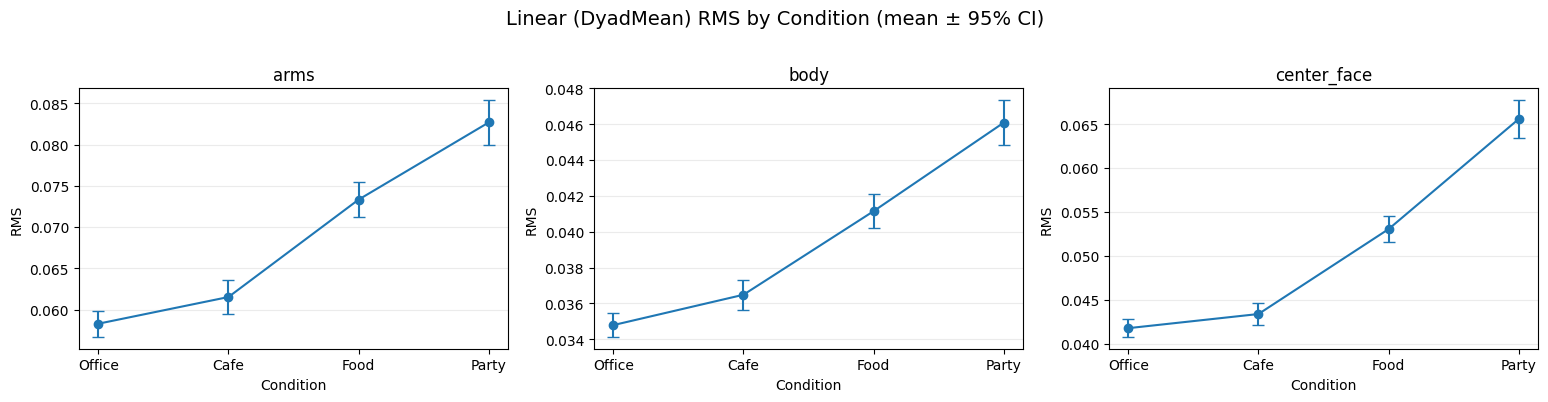

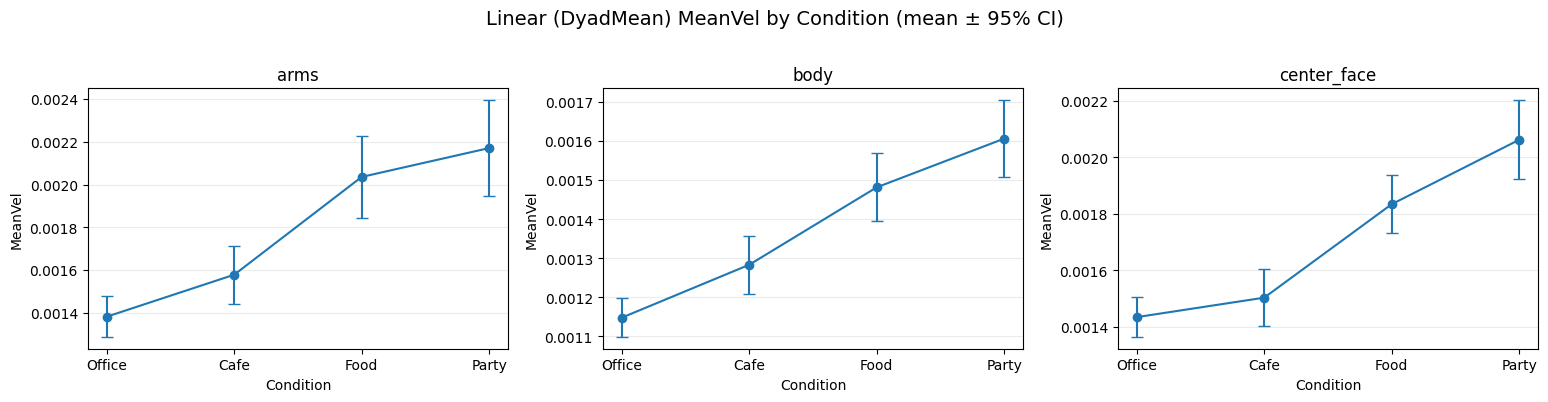

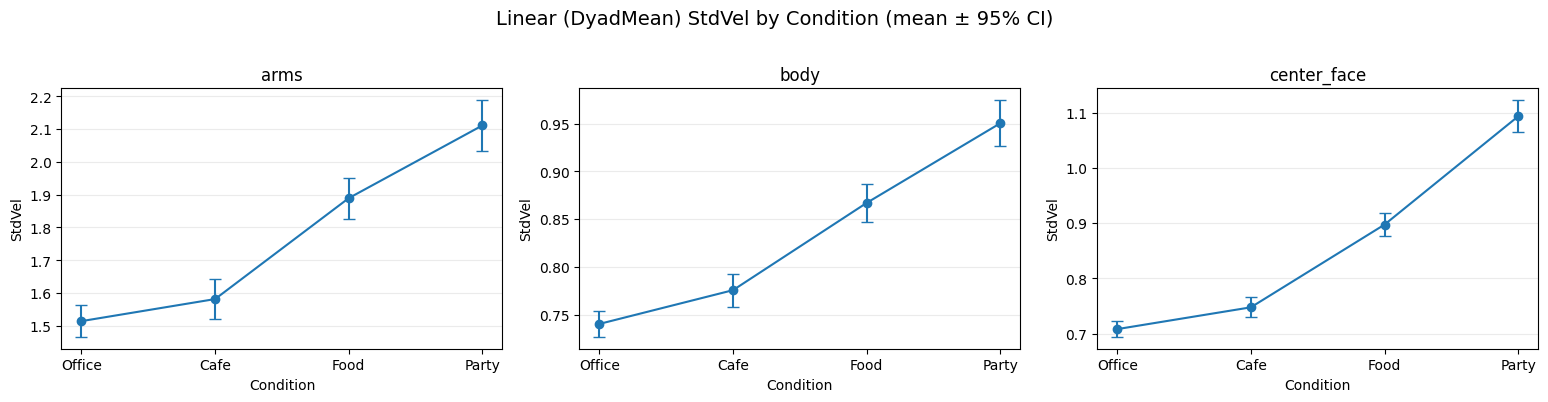

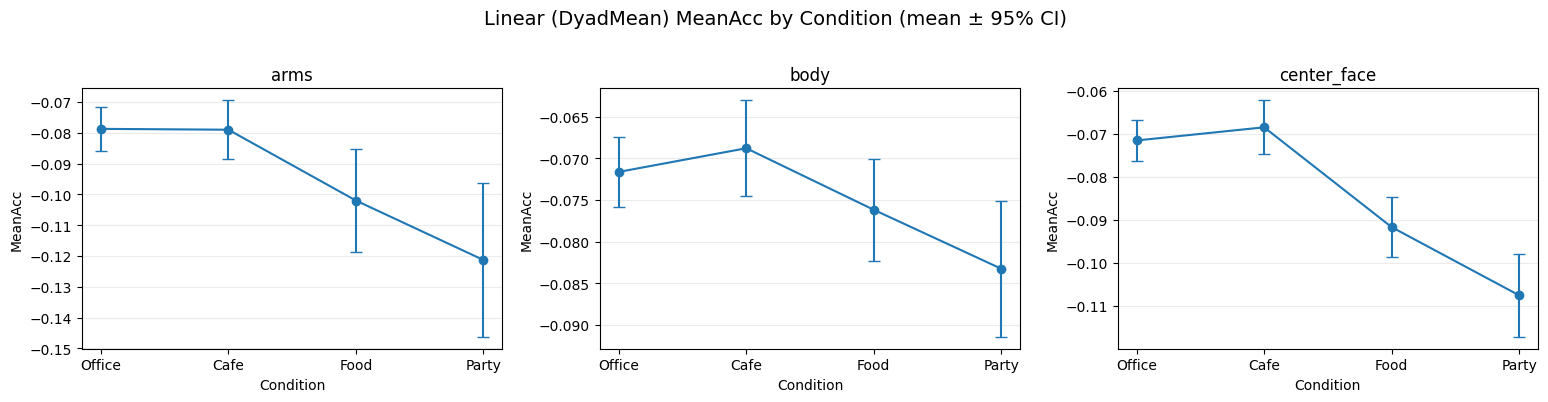

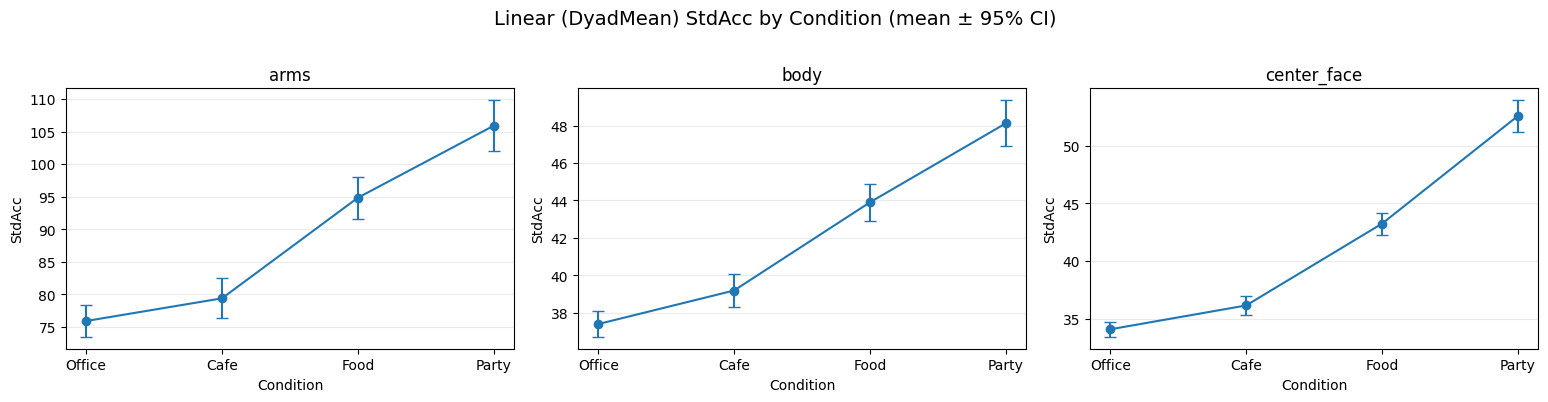

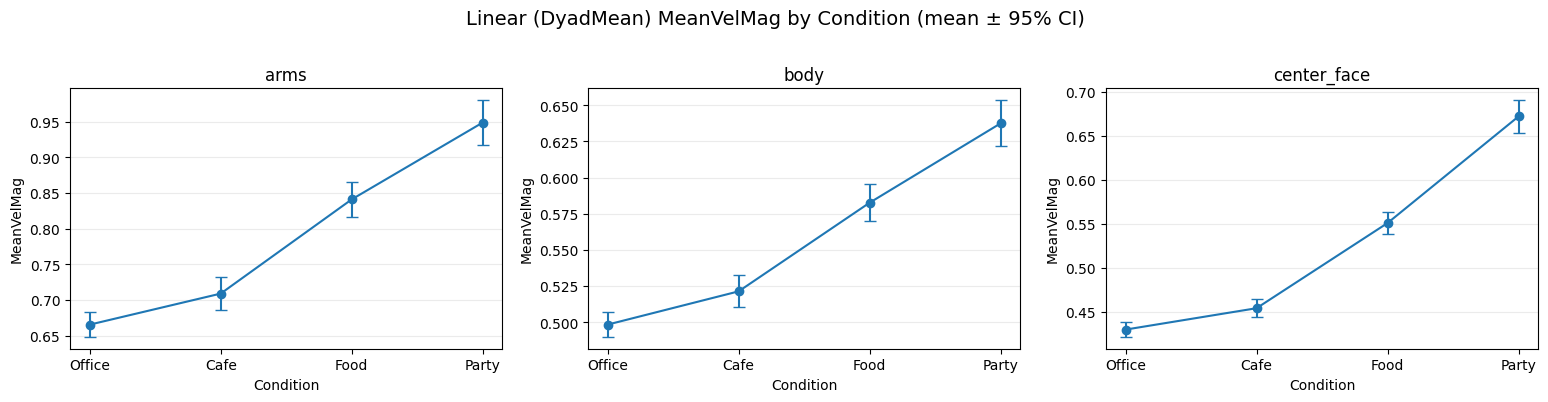

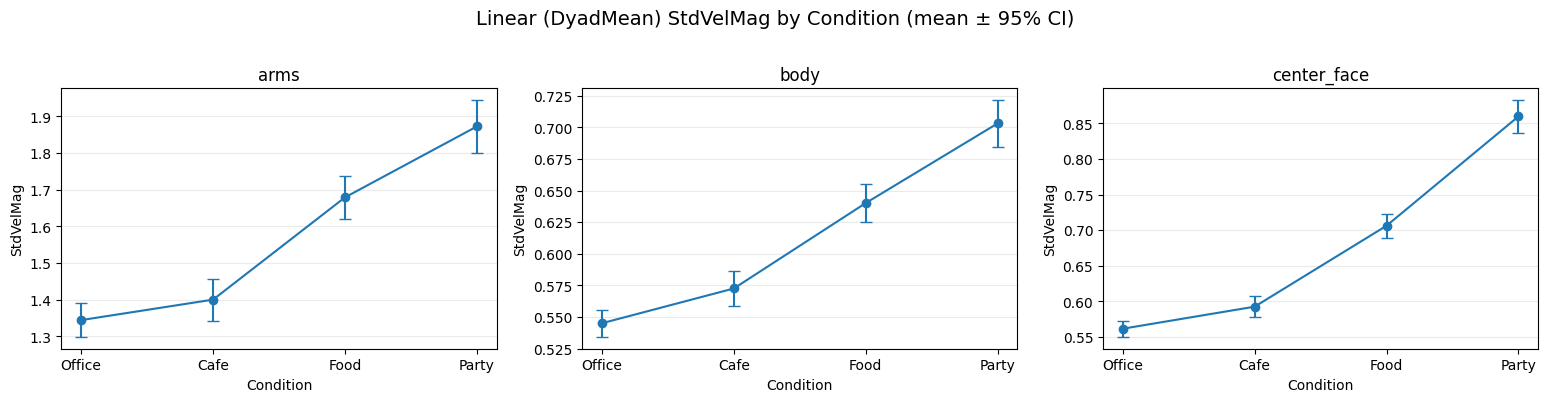

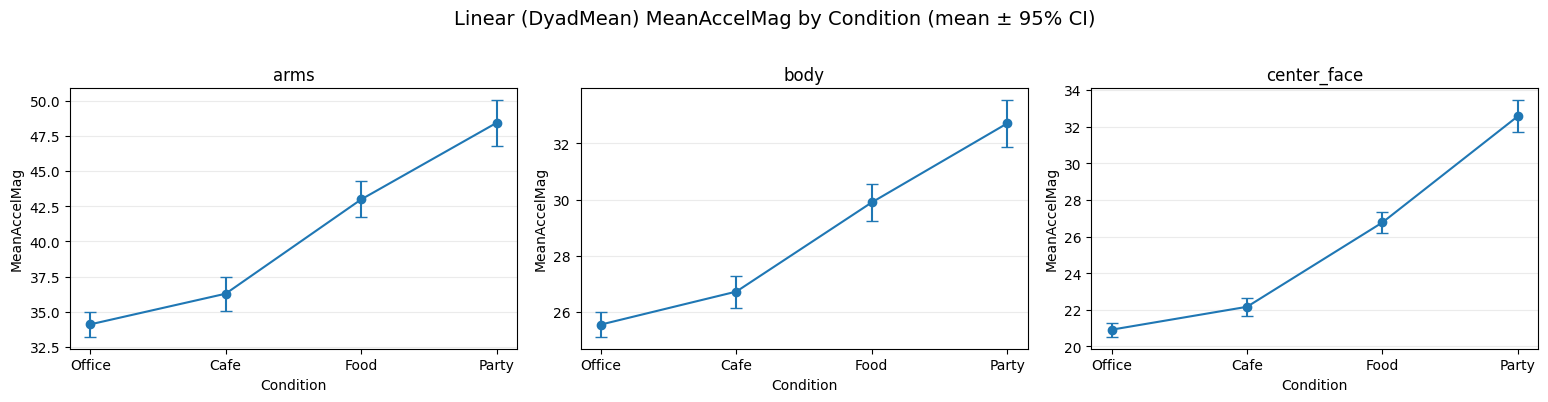

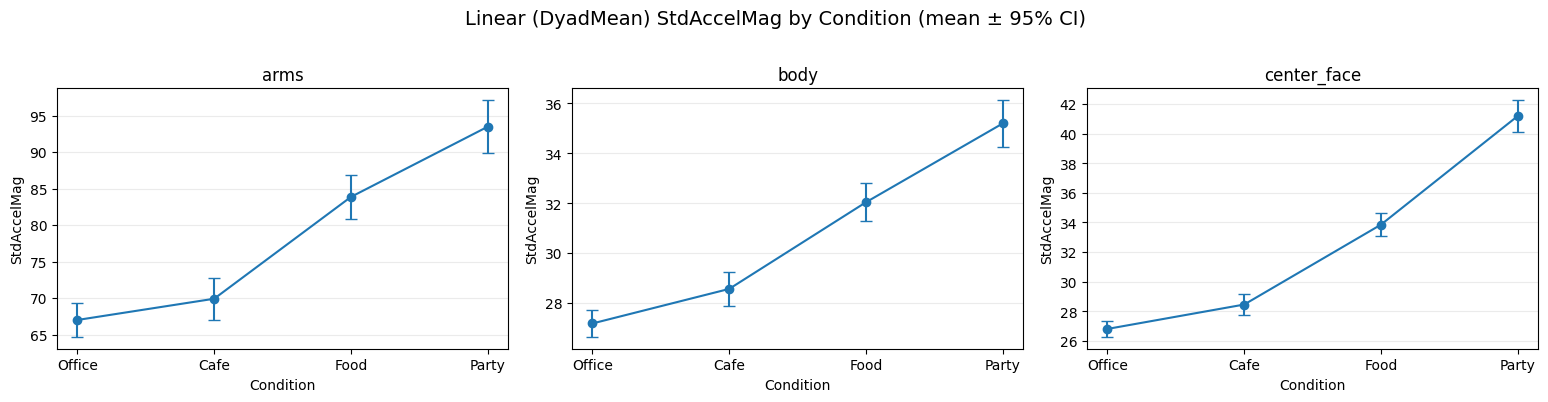

Loaded XCorr (paired only): (9342, 15)


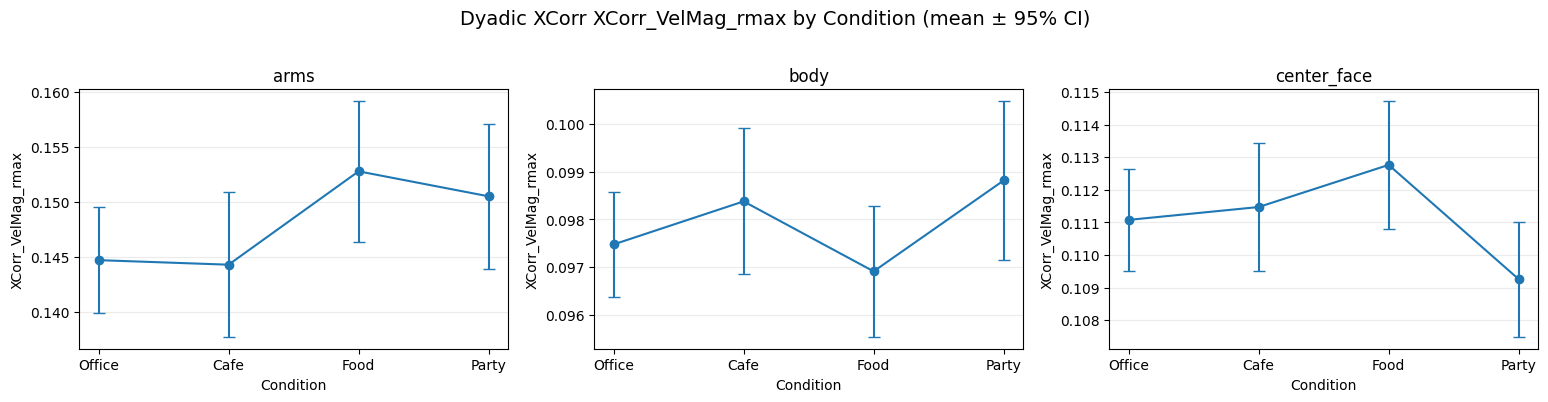

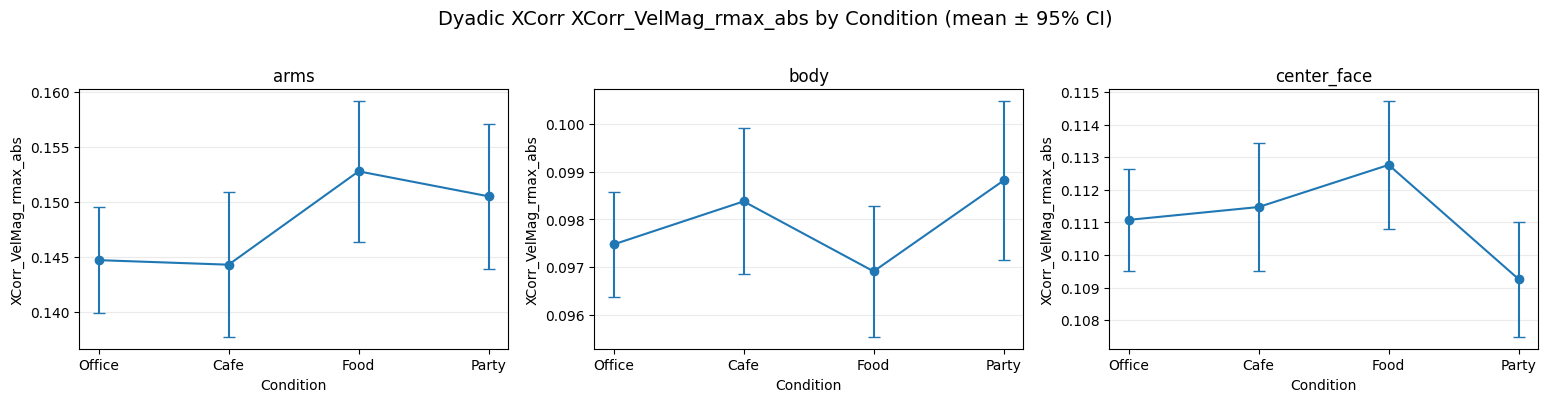

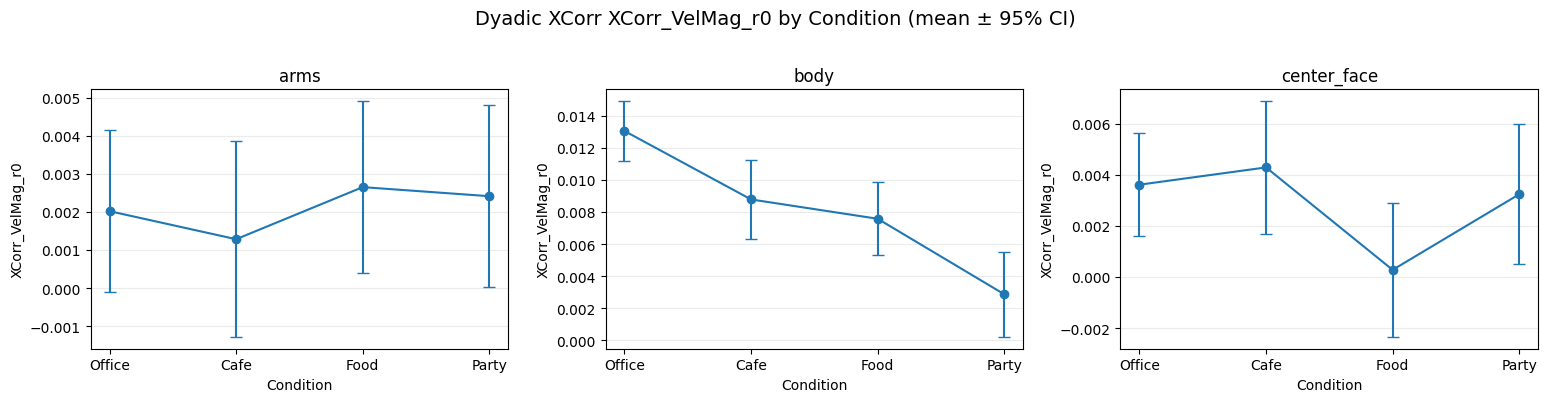

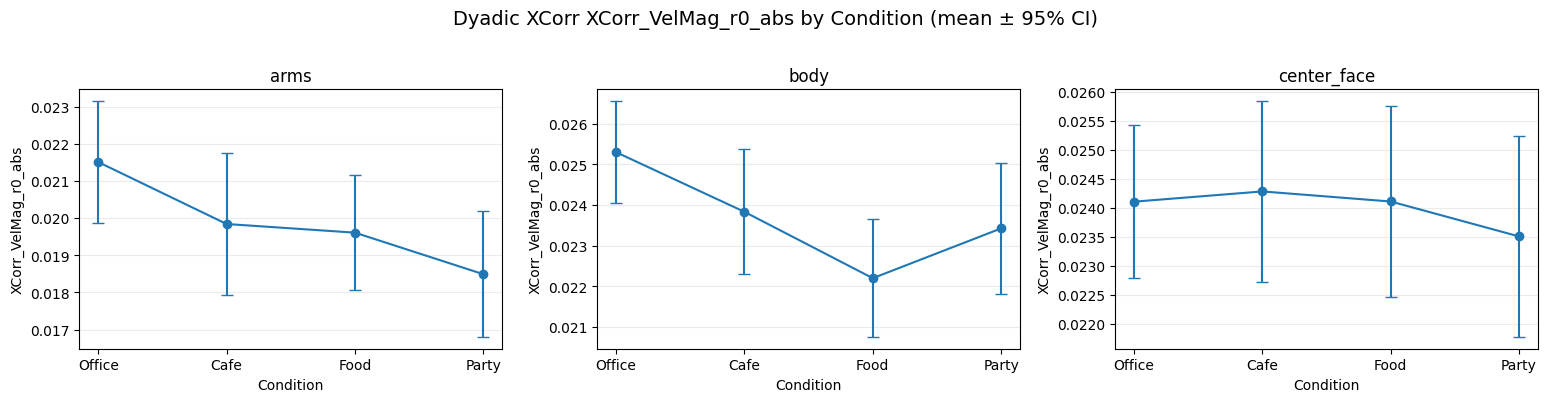

In [33]:

# Settings
CONDITION_ORDER = ["Office", "Cafe", "Food", "Party"]
SHOW_RAW_POINTS = False
CI_Z = 1.96
N_COLS = 3
JITTER = 0.15
POINT_ALPHA = 0.25
POINT_SIZE = 12

# Plot individual linear metrics
lin_df = load_linear_results_dyad_mean()
print("Loaded Linear (DyadMean):", lin_df.shape)

for m in ["RMS", "MeanVel", "StdVel", "MeanAcc", "StdAcc", "MeanVelMag", "StdVelMag", "MeanAccelMag", "StdAccelMag"]:
    if m in lin_df.columns:
        plot_by_condition_ci_grid(lin_df, m, title=f"Linear (DyadMean) {m} by Condition (mean ± 95% CI)")

# Plot dyadic linear (xcorr) metrics
xc_df = load_xcorr_results()
print("Loaded XCorr (paired only):", xc_df.shape)

for m in ["XCorr_VelMag_rmax", "XCorr_VelMag_rmax_abs", "XCorr_VelMag_r0", "XCorr_VelMag_r0_abs"]:
    if m in xc_df.columns:
        plot_by_condition_ci_grid(xc_df, m, title=f"Dyadic XCorr {m} by Condition (mean ± 95% CI)")

### Pass 8. (C)RQA Condition Plots

Loaded:
  CRQA : (7386, 17)
  RQA  : (19032, 19)


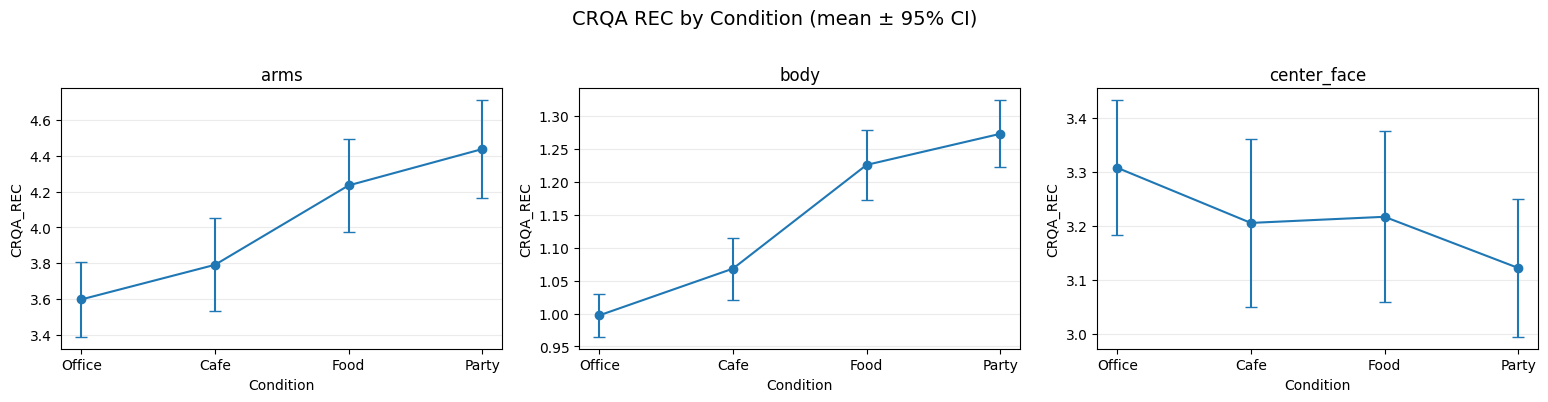

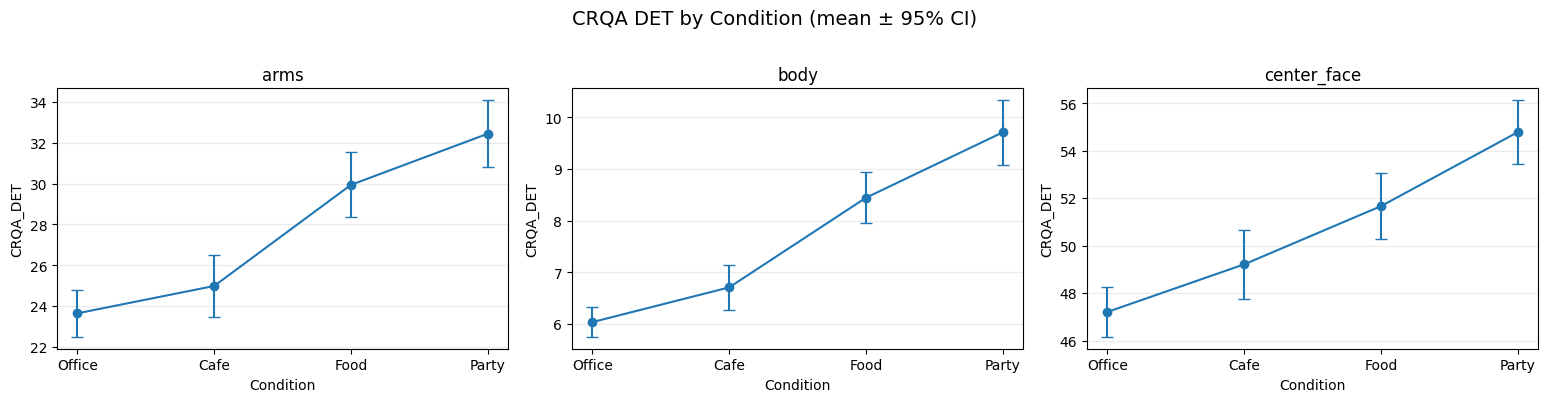

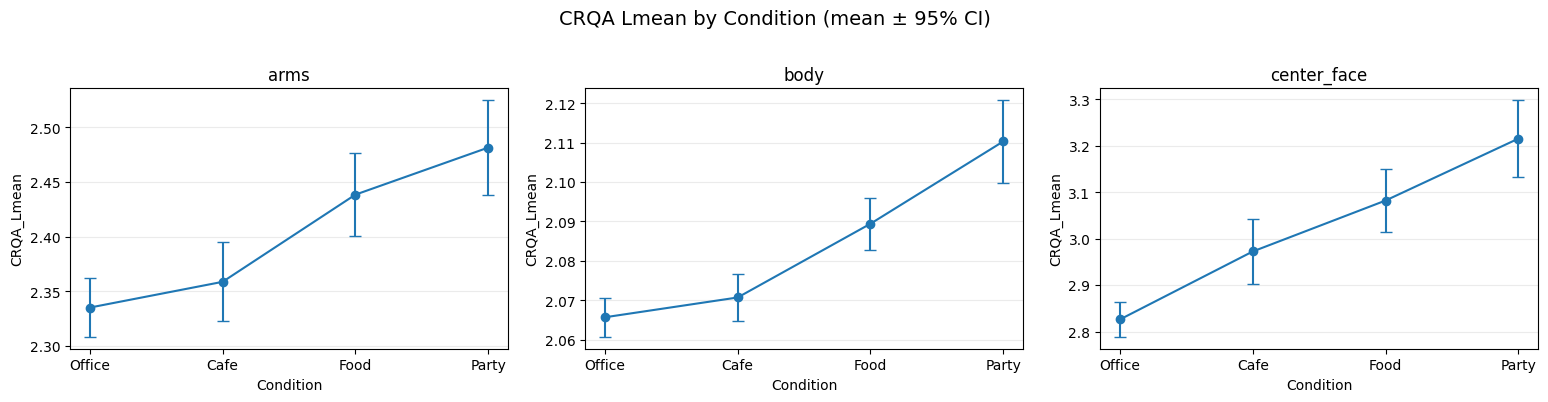

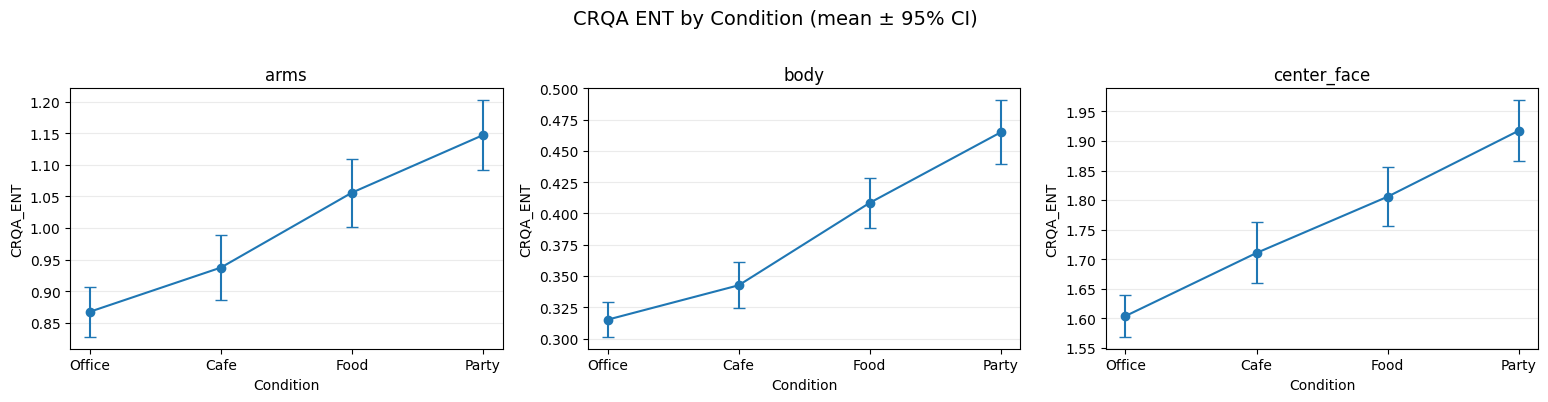

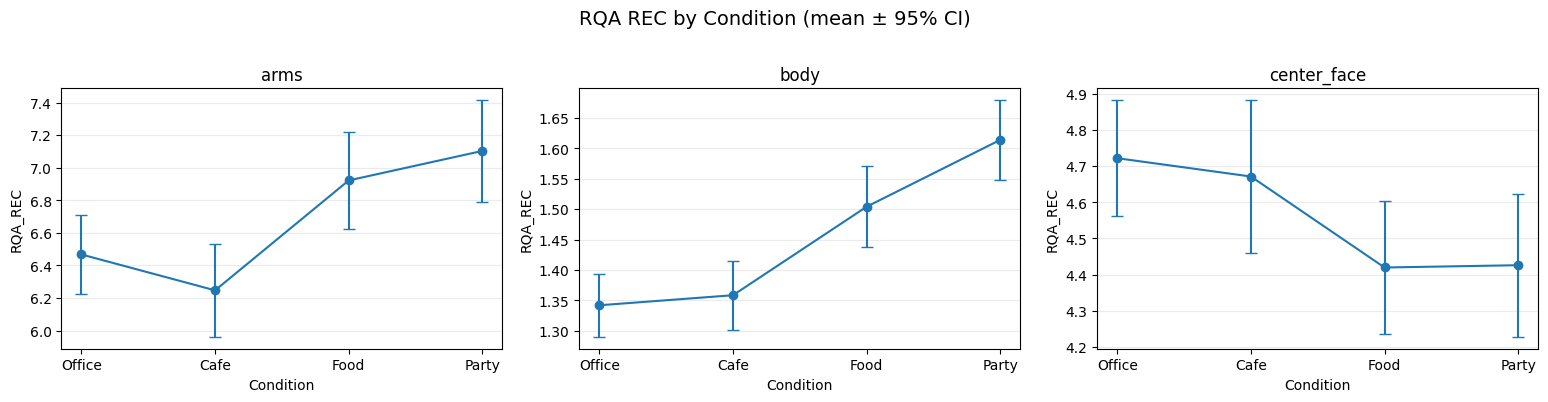

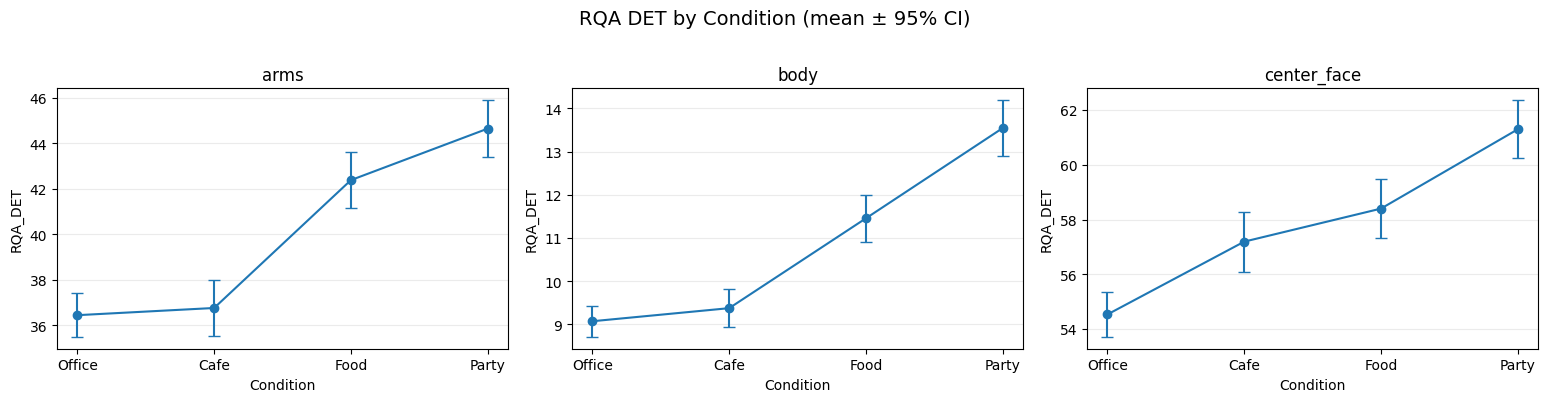

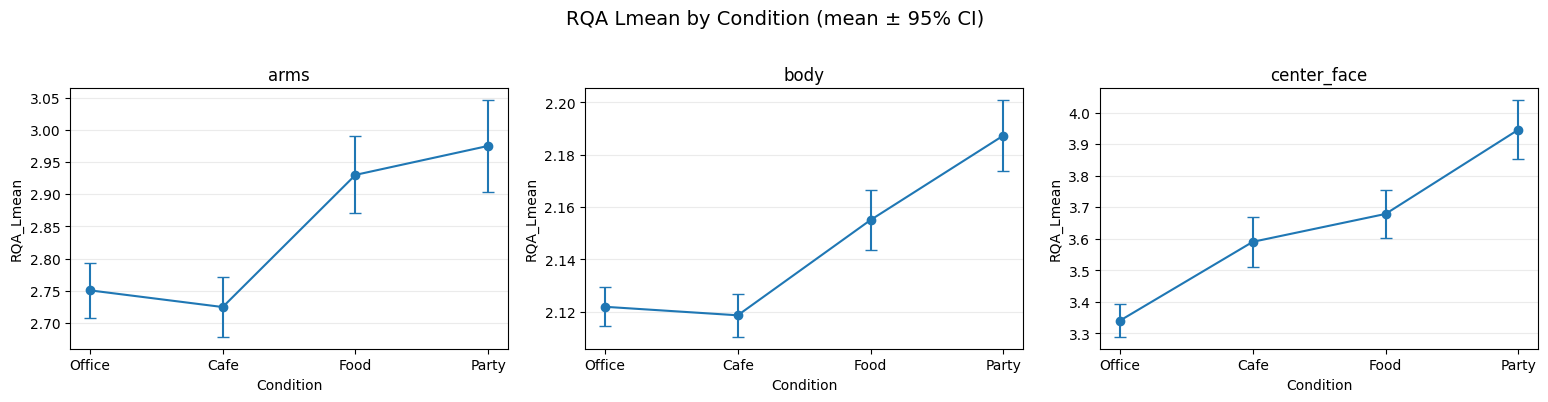

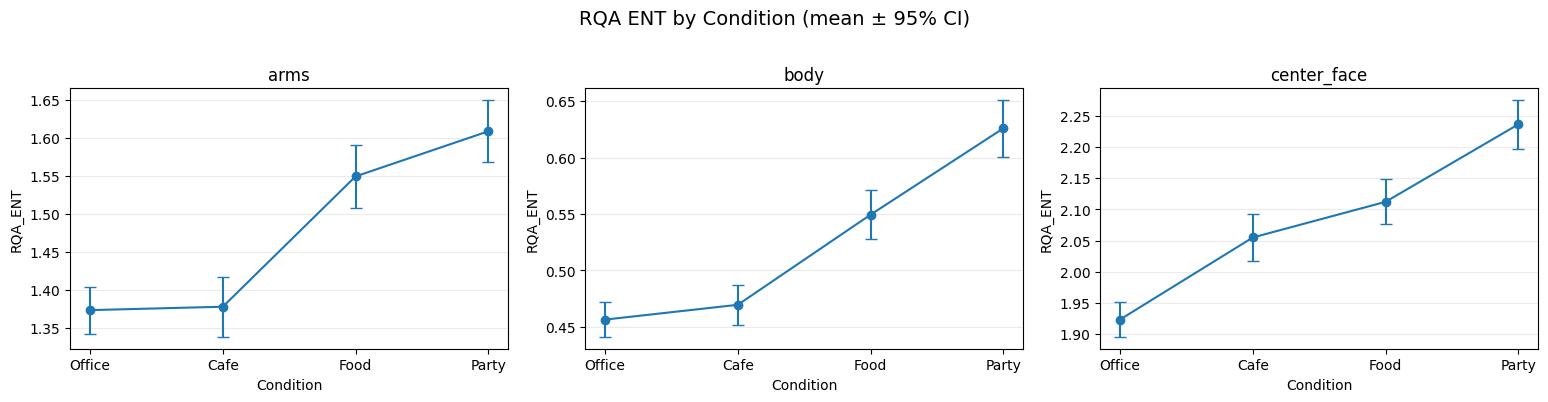

In [ ]:
# Settings
CONDITION_ORDER = ["Office", "Cafe", "Food", "Party"]
SHOW_RAW_POINTS = False      # <-- set True to show raw points
CI_Z = 1.96                 # 95% normal approx
N_COLS = 3                  # 3 plots per row
JITTER = 0.15
POINT_ALPHA = 0.25
POINT_SIZE = 12

# Helpers
def load_roi_results(kind: str):
    """
    kind: 'crqa' | 'rqa'
    """
    base_dir = f"../{kind}_results"
    files = [
        os.path.join(base_dir, f"{kind}_center_face_mag.csv"),
        os.path.join(base_dir, f"{kind}_body_mag.csv"),
        os.path.join(base_dir, f"{kind}_arms_mag.csv"),
    ]

    dfs = []
    for fp in files:
        if not os.path.exists(fp):
            print(f"[SKIP] Missing file: {fp}")
            continue
        dfs.append(pd.read_csv(fp))

    if not dfs:
        raise FileNotFoundError(f"No {kind} ROI files found in {base_dir}.")

    out = pd.concat(dfs, ignore_index=True)
    if "ROI" not in out.columns or "Condition" not in out.columns:
        raise ValueError(f"{kind} results missing ROI/Condition columns.")
    out = _set_condition_order(out)
    return out

# Plot RQA and CRQA results
crqa_df = load_roi_results("crqa")
rqa_df  = load_roi_results("rqa")

print("Loaded:")
print("  CRQA :", crqa_df.shape)
print("  RQA  :", rqa_df.shape)

# --- CRQA plots ---
plot_by_condition_ci_grid(crqa_df, "CRQA_REC",   title="CRQA REC by Condition (mean ± 95% CI)")
plot_by_condition_ci_grid(crqa_df, "CRQA_DET",   title="CRQA DET by Condition (mean ± 95% CI)")
plot_by_condition_ci_grid(crqa_df, "CRQA_Lmean", title="CRQA Lmean by Condition (mean ± 95% CI)")
plot_by_condition_ci_grid(crqa_df, "CRQA_ENT",   title="CRQA ENT by Condition (mean ± 95% CI)")

# --- RQA plots ---
plot_by_condition_ci_grid(rqa_df, "RQA_REC",   title="RQA REC by Condition (mean ± 95% CI)")
plot_by_condition_ci_grid(rqa_df, "RQA_DET",   title="RQA DET by Condition (mean ± 95% CI)")
plot_by_condition_ci_grid(rqa_df, "RQA_Lmean", title="RQA Lmean by Condition (mean ± 95% CI)")
plot_by_condition_ci_grid(rqa_df, "RQA_ENT",   title="RQA ENT by Condition (mean ± 95% CI)")

### (C)RQA Parameter Plots

FIX!

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil

# ============================
# User toggles
# ============================
CONDITION_ORDER = ["Office", "Cafe", "Food", "Party"]
SHOW_RAW_POINTS = False      # set True to show raw points
CI_Z = 1.96                 # 95% normal approx
N_COLS = 3                  # used elsewhere; not used in the param grid plot
JITTER = 0.15
POINT_ALPHA = 0.25
POINT_SIZE = 12

# ============================
# Helpers
# ============================

def _pick_col(df: pd.DataFrame, candidates, label: str):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(
        f"Could not find a '{label}' column. Tried: {candidates}\n"
        f"Available columns:\n{list(df.columns)}"
    )

def load_roi_results(kind: str):
    """
    kind: 'crqa' | 'rqa'
    Loads and concatenates ROI csvs.
    """
    base_dir = f"../{kind}_results"
    files = [
        os.path.join(base_dir, f"{kind}_center_face_mag.csv"),
        os.path.join(base_dir, f"{kind}_body_mag.csv"),
        os.path.join(base_dir, f"{kind}_arms_mag.csv"),
    ]

    dfs = []
    for fp in files:
        if not os.path.exists(fp):
            print(f"[SKIP] Missing file: {fp}")
            continue
        dfs.append(pd.read_csv(fp))

    if not dfs:
        raise FileNotFoundError(f"No {kind} ROI files found in {base_dir}.")

    out = pd.concat(dfs, ignore_index=True)
    if "ROI" not in out.columns or "Condition" not in out.columns:
        raise ValueError(f"{kind} results missing ROI/Condition columns.")
    out = _set_condition_order(out)
    return out

def plot_crqa_rec_by_params(
    df: pd.DataFrame,
    rec_col: str = "CRQA_REC",
    title_prefix: str = "CRQA REC",
):
    """
    For each ROI:
      - subplots: embedding_dim (rows) × radius (cols)
      - x: Condition
      - y: mean ± 95% CI of CRQA_REC
      - separate line per tLag
    """

    if rec_col not in df.columns:
        raise ValueError(
            f"'{rec_col}' not found in df. Available columns:\n{list(df.columns)}"
        )

    # --- auto-detect parameter columns (adjust candidates if your headers differ) ---
    emb_col = _pick_col(df, ["Embedding_Dim"], "embedding dimension")
    rad_col = _pick_col(df, ["Radius"], "radius")
    tlag_col = _pick_col(df, ["Lag"], "tLag")

    print(f"[INFO] Using columns: emb='{emb_col}', radius='{rad_col}', tLag='{tlag_col}', DV='{rec_col}'")

    d = df.copy()
    d = _set_condition_order(d)

    # make sure radius is sortable numeric if possible
    d[rad_col] = pd.to_numeric(d[rad_col], errors="ignore")
    d[emb_col] = pd.to_numeric(d[emb_col], errors="ignore")
    d[tlag_col] = pd.to_numeric(d[tlag_col], errors="ignore")

    rois = [r for r in sorted(d["ROI"].dropna().unique())]
    if not rois:
        print("[SKIP] No ROIs found.")
        return

    for roi in rois:
        sub_roi = d[d["ROI"] == roi].copy()
        if sub_roi.empty:
            continue

        emb_vals = sorted(pd.Series(sub_roi[emb_col].dropna().unique()).tolist())
        rad_vals = sorted(pd.Series(sub_roi[rad_col].dropna().unique()).tolist())

        if len(emb_vals) == 0 or len(rad_vals) == 0:
            print(f"[SKIP] ROI={roi} missing emb/radius values.")
            continue

        nrows = len(emb_vals)
        ncols = len(rad_vals)

        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(4.8 * ncols, 3.8 * nrows),
            squeeze=False
        )

        # One legend for whole figure
        legend_handles = None
        legend_labels = None

        cats = list(sub_roi["Condition"].cat.categories)
        x = np.arange(len(cats))

        for i, emb in enumerate(emb_vals):
            for j, rad in enumerate(rad_vals):
                ax = axes[i, j]
                cell = sub_roi[(sub_roi[emb_col] == emb) & (sub_roi[rad_col] == rad)].copy()

                if cell.empty:
                    ax.set_title(f"m={emb}, r={rad}\n(no data)")
                    ax.set_xticks(x)
                    ax.set_xticklabels(cats, rotation=0)
                    ax.grid(True, axis="y", alpha=0.25)
                    continue

                # plot each tLag as its own line (mean ± CI by Condition)
                tlag_vals = sorted(pd.Series(cell[tlag_col].dropna().unique()).tolist())

                for tl in tlag_vals:
                    cell_t = cell[cell[tlag_col] == tl].copy()

                    stats = []
                    for cond in cats:
                        mean, lo, hi, n_obs = _mean_ci(cell_t.loc[cell_t["Condition"] == cond, rec_col])
                        stats.append((cond, mean, lo, hi, n_obs))
                    stats_df = pd.DataFrame(stats, columns=["Condition", "mean", "lo", "hi", "n"])

                    y = stats_df["mean"].to_numpy()
                    yerr = np.vstack([(y - stats_df["lo"].to_numpy()),
                                      (stats_df["hi"].to_numpy() - y)])

                    # optional raw points (per tLag) — can get messy fast
                    if SHOW_RAW_POINTS:
                        pts = cell_t.dropna(subset=["Condition", rec_col]).copy()
                        if not pts.empty:
                            x_codes = pts["Condition"].cat.codes.to_numpy()
                            jitter = (np.random.rand(len(x_codes)) - 0.5) * (2 * JITTER)
                            ax.scatter(
                                x_codes + jitter,
                                pd.to_numeric(pts[rec_col], errors="coerce").to_numpy(),
                                alpha=POINT_ALPHA,
                                s=POINT_SIZE,
                            )

                    ax.errorbar(x, y, yerr=yerr, fmt="-o", capsize=3, label=f"{tlag_col}={tl}")

                ax.set_title(f"m={emb}, r={rad}")
                ax.set_xticks(x)
                ax.set_xticklabels(cats)
                if j == 0:
                    ax.set_ylabel(rec_col)
                ax.set_xlabel("Condition")
                ax.grid(True, axis="y", alpha=0.25)

                # grab legend entries once
                if legend_handles is None:
                    legend_handles, legend_labels = ax.get_legend_handles_labels()

        fig.suptitle(f"{title_prefix} by Condition — ROI: {roi}\n(rows=m, cols=radius; lines=tLag)", y=1.02, fontsize=14)
        if legend_handles and legend_labels:
            fig.legend(legend_handles, legend_labels, loc="upper right", bbox_to_anchor=(1.02, 1.02))
        fig.tight_layout()
        plt.show()


# ============================================================
# LOAD + PLOT (CRQA REC ONLY)
# ============================================================
crqa_df = load_roi_results("crqa")
print("Loaded CRQA:", crqa_df.shape)

plot_crqa_rec_by_params(crqa_df, rec_col="CRQA_REC", title_prefix="CRQA REC")
